In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor
from tabpfn import TabPFNRegressor
from sklearn.neural_network import MLPRegressor

import warnings
warnings.filterwarnings('ignore')

import openml
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from xgboost import XGBClassifier, XGBRegressor
from tabpfn import TabPFNClassifier, TabPFNRegressor
import optuna
from scipy.stats import wilcoxon
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Create output directory for saving results
import os
os.makedirs('output', exist_ok=True)
print('Output directory created/verified')

Output directory created/verified


# Accurate Predictions on Small Data with a Tabular Foundation Model (TabPFN) - Summary

_______

**Paper information** <br> <br>

**Title:** Accurate predictions on small data with a tabular foundation model
<br>
**Authors:** Noah Hollmann, Samuel Müller, Lennart Purucker, Arjun Krishnakumar, Max Körfer, Shi Bin Hoo, Robin Tibor Schirrmeister, Frank Hutter
<br>
**Published:** Nature, Vol 637, January 9, 2025
<br>
**DOI:** https://doi.org/10.1038/s41586-024-08328-6

______

Summary includes some additional clarifications, so that certain concepts become clearer for the summarizer. These do not alter the paper's main ideas and the presented findings in any way.

______

## Overview

This paper presents TabPFN (Tabular Prior-data Fitted Network), a revolutionary new approach to making predictions from tabular data (e.g. spreadsheets in Excel). The remarkable achievement is that TabPFN can make better predictions than all previous methods on datasets with up to $10,000$ rows, while being $5,140$ times faster for classification tasks, and $3,000$ times faster for regression tasks than traditional approaches.

### Historical Context

Throughout the history of artificial intelligence, there’s been a consistent pattern: hand-designed components get replaced by learned ones:
<br><br>
**Computer Vision (Recognizing Images):**
- Old way: Human experts manually designed features to detect edges, corners, and shapes (like SIFT
[Lowe 2004] and HOG [Dalal & Triggs 2005] ) <br>
- New way: Deep learning networks automatically learn what features are important

**Natural Language Processing (Understanding Text):**
- Old way: Linguists manually created grammar rules <br>
- New way: Transformer models [Vaswani et al. 2017] learn language patterns automatically

**Game Playing:**
- Old way: Human experts created opening move libraries and endgame strategies
- New way: End-to-end learning systems like AlphaGo [Silver et al. 2016, 2017] learn strategies auto‐
matically
<br><br>
This paper extends this paradigm shift to **tabular data** - the most common form of data in science and business. The authors demonstrate how **TabPFN** outperforms state-of-the-art baselines, such as gradient-boosted decision trees, even with $4$h of tuning.

### Tabular data

**Definition:** Information organized in rows (observations, samples) and columns (features).
<br><br>

**Why is Tabular Data different than other types of data, e.g. Images or Text?** 
<br>
The key challenge with tabular data is **heterogeneity**. <br>
For instance, in language modeling words tend to preserve their meaning across documents, while each **tabular dataset** is **fundamentally unique** and what works for one tabular dataset may not be applicable for another. This leads to:
- Many small independent datasets and associated models. E.g. $76\%$ of datasets on ```openml.org``` contain less than $10,000$ rows at the time of this paper's writing.
- Difficulty to transfer knowledge between datasets.
- Challenges for deep-learning methods that typically need large amounts of consistent data, and the preferrence of non-deep-learning methods, such as tree-based models.

Possible types of data in tabular datasets include:
- Booleans
- Categorical
- Ordinal
- Integers
- FLoating Points

Tabular data presents further challenges, such as:
- Missing values: E.g. some measurements weren't recorded
- Imbalanced data: E.g. only a small percentage of people have a certain disease
- Outliers
- Features that are carry very little significance for the prediction of the outcome

Traditional machine learning methods fall short because of:
- Poor out-of-distribution predictions
- Poor transfer learning
- Inability to combine with neural networks, as gradients are not propagated
- Time-consuming tuning

TabPFN provides:
- Superior performance
- Faster speed than tuned baseline methods
- Additional capabilities for e.g. fine-tuning and data generation
- Gradient compatibility (can be integrated with neural network pipelines)

## Methodology of TabPFN

### In-context learning (ICL)

**In-context learning (ICL)** is the same mechanism that enabled large language models (e.g. GPT) to be very powerful, and is also utilized by TabPFN to generate predictions from tabular data. The TabPFN algorithm consists of a **data generation phase**, **pre-training phase** done once on the millions of diverse generated synthetic prediction tasks from the previous step, and **inference phase** for the new dataset, with no retraining necessary.

TODO: insert and explain Figure 1. Figure 2.

Transformers are a type of neural network architecture that transforms or changes an input sequence into an output sequence. It has been shown that transformers can learn simple algorithms (e.g. logistic regression), as well as more complex algorithms (e.g. Gaussian processes, Bayesian Neural Networks) via ICL. Therefore, **ICL enables the learning of a wider space of possible algorithms**, including cases where closed-form solutions do not exist. [Muller et al., 2023]

The key concept behind TabPFN is:
- Generate a very large corpus of synthetic diverse tabular datasets, designed to capture a wide range of potential scenarios, and then have taget values masked for a subset of samples for every dataset.
- Train a transformer model (the PFN) to predict masked targets of all synthetic datasets, a step done only once, with the result of a generic learning algorithm that can be used to predict any dataset.
- Apply trained model to unseen arbitrary real-world datasets. Training samples are used as model context, which predicts the labels of the unseen datasets through ICL.

This approach can be viewed as approximating Bayesian prediction for a prior defined by the synthetic datasets. The trained PFN will approximate the posterior predictive distribution $ p(\hat{\vec{y_{\text{test}}} \vert \vec{X_{\text{test}}}, \vec{X_{\text{test}}}, \vec{y_{\text{train}}} ) $, and return a Bayesian prediction for the specified distribution over artificial datasets used in the pre-training phase. 

### TabFPN Training - further information

The training objective is the minimization of the loss function:

$$\text{Loss} = -\log q_\theta(Y_{\text{test}} | X_{\text{test}}, X_{\text{train}}, Y_{\text{train}})$$

- $q_\theta$: The model’s predicted probability distribution ($\theta$ represents all the model parameters/weights). The model predicts a probability distribution over possible values.
- $Y_{\text{test}}$: The true target values we’re trying to predict
- $X_{\text{test}}$: The features of the test samples
- $X_{\text{train}}$: The features of the training samples (provided as context)
- $Y_{\text{train}}$: The target values of the training samples (provided as context)
- Logarithm: mathematically convenient, converts tiny probabilities to larger numbers.

The model was pre-trained:
- on $8$ NVIDIA RTX 2080 GPUs
- over $2$ weeks of time

### Architecture

TabFPN uses a **two-dimensional attention mechanism** that respects the table's structure. This addresses the limitation of other tansformer models' architectures that they are treating input data as a single sequence.

TabFPN architecture assigns a separate representation to each cell in the table, so each cell has its own "embedding" - a vector of numbers that captures that cell's information. 

TODO: maybe insert and explain Fig 1 (b) here

The model performs **Feature attention (Horizontal)** and **Sample attention (Vectical)**. This captures row and column patterns, so helps understand both relationships between features within a sample, and distributions of each feature. It is order invariant, so shifting rows or columns doesn't change predictions. Finally, it is scalable, although the authors note scalability to larger datasets requires further study.

### Technical optimizations

#### Fit-predict optimization

In the standard ICL set-up, when multiple test samples need to be predicted, training data needs to be reprocced each time. TabFPN processes training data **once**, saves its initial state, and reuses it for all test predictions. This achieves a speedup of $300$ times for datasets with $10,000$ rows and $10$ features (CPU) and $800$ times for datasets of $10,000$ rows and $100$ features (CPU). These metrics are a bit lower for GPU: $6$ times faster for the first dataset type and $30$ times for the latter. This is due to the underutilization of the GPU parallel architectures.

#### Memory optimization

Memory requirements are reduced $4$ times with:
- half-precision layer norms: storing some computations using $16$-bit floats, instead of $32$-bits
- flash attention: an optimized algorithm for computing attention that uses less memory with no compromise made on accuracy [Dao, T. et al., 2022]
- activation checkpoints: not storing all intermediate computations during forward pass (when input data is sent through to produce output), but recompute during backward pass (backpropagation of the error)
- sequential state computation: process samples one at a time

#### Optimization for regressions

TabFPN uses **piece-wise constant distribution** for regression tasks, allowing the prediction of target value distributions, instead of single values. This may help capture for e.g. uncertainty (how wide is a distribution) or multimodality.


### Generating synthetic data

The approach of Pearl (2009) is used to generate synthetic data - that of **structural causal models**. Causal models represent how different variables influence ("cause") eachother. This is useful for tabular data, as such causal relationship may exist between different features.

Synthetic data also helps avoid copyright infringements, data contamination (i.e. contaminating the training data with test data) and data privacy violations.

TODO: Fig 2. here


#### Generation principle

1. Decide the overall dataset properties (e.g. size, number of features, number of classes for classification, noise level)
2. Build computational graph structure

Here directed acyclic graph (DAG) is used, where:
- nodes: variables/intermediate computations
- edges: functions to transform inputs to outputs
- flow: information flows from parent to child nodes

Each edge applies a transformation:

**Neural Network edges:**
- ReLU (Rectified Linear Unit): $\text{ReLU}(x) = \max(0,x)$ - "clips" negative values to zero
- Sigmoid: $\sigma(x) = \frac{1}{1+e^{-x}}$ - "restrict" values to the range $[0,1]$
- Sine: $\sin{x}$ - create periodic oscillations
- Modulo: $x \mod k$ - create repeating patterns

**Tree edges:** to create local, rule-based dependencies - patterns that can change abruptly at boundaries

**Discretization edges:** to generate categorical features in the synthetic data

We also **add noise** to edges (Gaussian noise): i.e. $y = f(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0,\sigma^2)$, Normally distributed noise with mean $0$ and variance ("level" of noise) $\sigma^2$

3. Generate samples by propagating initialization data

For each sample $i$ initializa sample data, with random noise genearation for root nodes. Vary sample dependence: each sample's noise can be completely random (fully independent sample), or some correlation between samples may exist (partially dependend samples). 

Then, propagate through the graph: starting from root nodes, we compute each subsequent node's value by applying edge transformations. We store intermediate representations - save the computed value at each node to later select from these for our features and targets.

4. Sample feature and target positions

Features and targets can come from any of the nodes in the DAG. This diversity prepares for the "real-world", as in real datasets we don't know the true causal structure.

5. Post-processing

We apply final transformations to make data more complex and real-world like.

- Apply the distribution from Kumaraswamy, 1980. This will create non-linear distortions: $K(x; a,b) = 1 - (1-x^a)^b$ with $a,b$ being shape parameters for the Kumaraswamy distribution.
- Quantization - round continuous values to simulate discrete features (e.g. for integer features, or low precision measurements)
- Missing values - Randomly remove values from features
- Create outliers
- Add unimportant features

#### Further on the mathematical foundations

TabFPN can be viewed as approximating **Bayesian prediction**. Thus, it incorporates:
- prior knowledge (what we know before seeing the data)
- evidence (data)
- posterior (updated beliefs after seeing the data)

Goal is to compute the **posterior predictive distribution**:

$$p(Y_{\text{new}} | X_{\text{new}}, X_{\text{train}}, Y_{\text{train}})$$

Here:
- $Y_{\text{new}}$: Target value we want to predict
- $X_{\text{new}}$: Features of the new sample
- $X_{\text{train}}$: Features of training samples (what we observe)
- $Y_{\text{train}}$: Targets of training samples (what we observe)
- $p(\cdot | \cdot)$: Probability distribution conditioned on observations


To compute this, we consider all possible models:

$$p(Y_{\text{new}} | X_{\text{new}}, X_{\text{train}}, Y_{\text{train}}) = \int p(Y_{\text{new}} |
X_{\text{new}}, \theta) \cdot p(\theta | X_{\text{train}}, Y_{\text{train}}) \, d\theta$$

,where:
- $\theta$: Represents a specific model (e.g., specific values for all parameters)
- $p(Y_{\text{new}} | X_{\text{new}}, \theta)$: Likelihood of target given features and a specific model (prediction made by model $\theta$)
- $\int … d\theta$: average over all models, weighted by their posterior probability
- $p(\theta | X_{\text{train}}, Y_{\text{train}})$: “Posterior probability of model $\theta$ given training data”

The latter computed using Bayes’ theorem will be:
$$p(\theta | X_{\text{train}}, Y_{\text{train}}) = \frac{p(Y_{\text{train}} | X_{\text{train}}, \theta)
\cdot p(\theta)}{p(Y_{\text{train}} | X_{\text{train}})}$$

, where:
- $p(\theta)$: Prior - what we believed about models before seeing data
- $p(Y_{\text{train}} | X_{\text{train}}, \theta)$: how well model $\theta$ explains the training data
- $p(Y_{\text{train}} | X_{\text{train}})$: Evidence - normalizing constant


TabFPN learns to **approximate** the Bayesian posterior predictive distribution through ICL. So, the trained model $q_\theta$ approximates (w.r.t the prior defined by the synthetic data generation process):

$$q_\theta(Y_{\text{new}} | X_{\text{new}}, X_{\text{train}}, Y_{\text{train}}) \approx p(Y_{\text{new}} | X_{\text{new}}, X_{\text{train}}, Y_{\text{train}})$$


TabFPN's attention mechanism is somewhat simulating gradient descend - the model learns during pretraining how to look at training examples, discover patterns, adjust internal representations and make predictions on those examples.

## Experimental Results


### Qualitative analysis on toy problems


**Experiment 1**

Testing TabFPN's behaviour and that of a set of baselines on simple functions.

With the below code, we test model predictions vs. true function for functions of the types: 
- $\sin{(x)}+x$,
- $x^2$,
- $\vert x \vert$,
- and a step function.

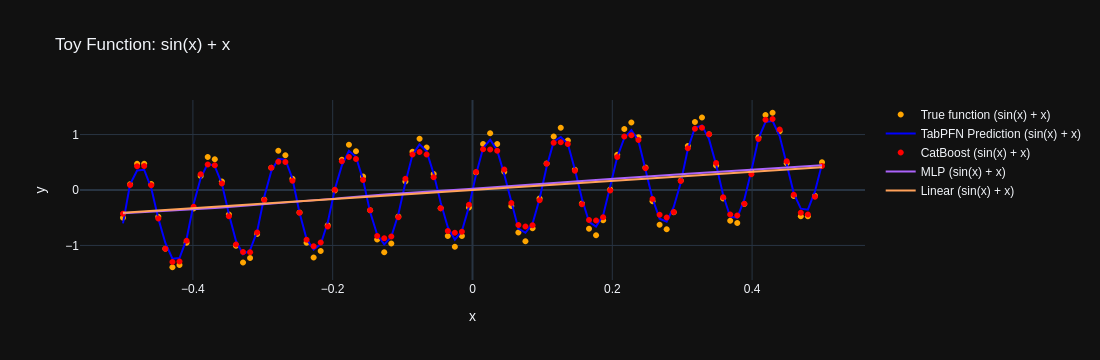

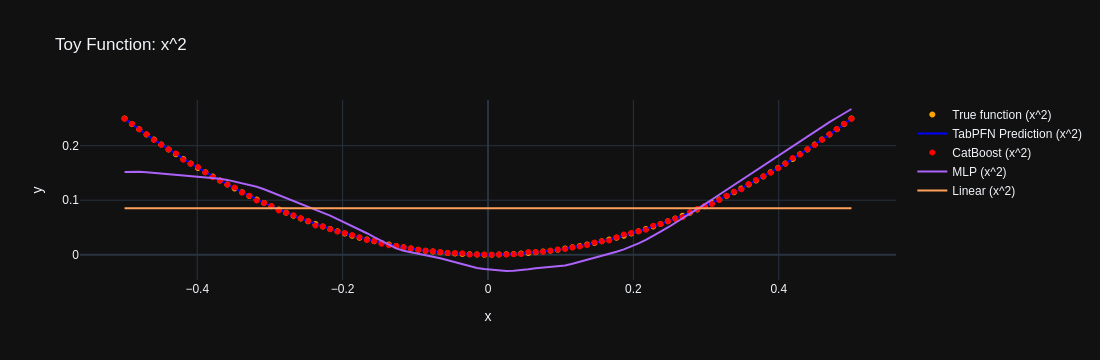

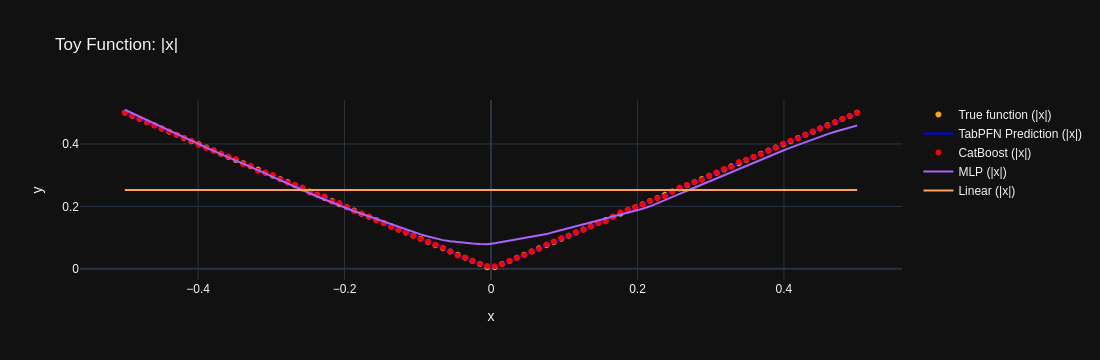

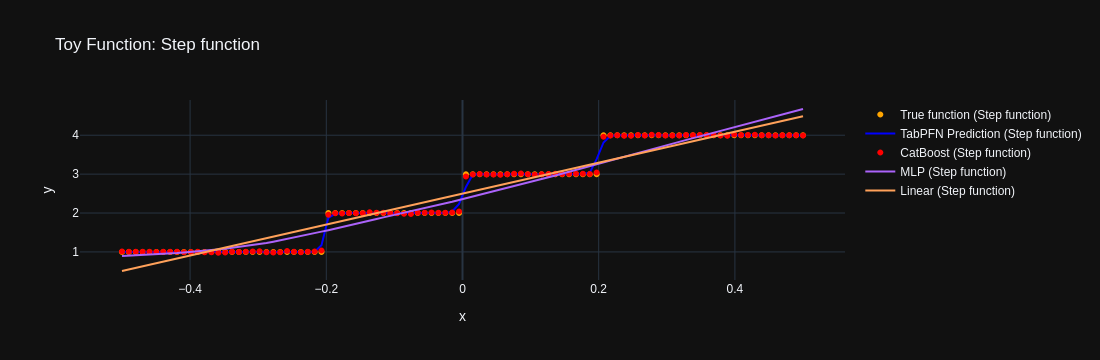

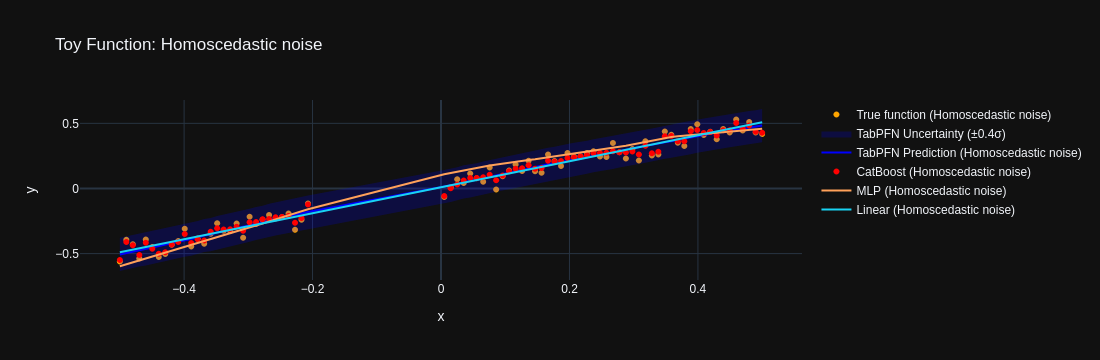

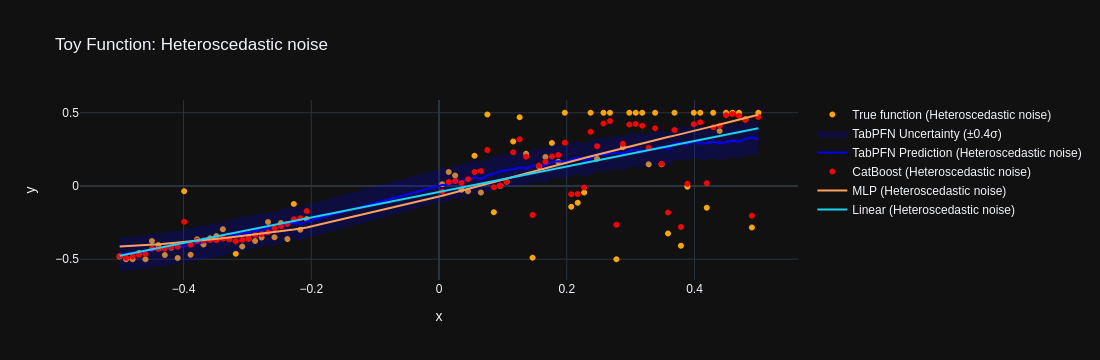

In [2]:
"""
Toy Function Regression Visualization Module

This module implements various toy functions (sinusoidal, polynomial, absolute value,
and step functions) and compares the performance of different regression models
(TabPFN, CatBoost, MLP, Linear Regression) on these functions.

The module provides interactive Plotly visualizations to compare model predictions
against true function outputs.
"""

from typing import Callable, Dict, List, Tuple, Union
import numpy as np
import numpy.typing as npt
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from tabpfn import TabPFNRegressor
import plotly.graph_objects as go


# Type aliases for better readability
NDArrayFloat = npt.NDArray[np.float64]
ModelDict = Dict[str, Union[TabPFNRegressor, CatBoostRegressor, MLPRegressor, LinearRegression]]
PredictionDict = Dict[str, NDArrayFloat]


# ============================================================================
# Toy Functions
# ============================================================================

def f1(x: NDArrayFloat) -> NDArrayFloat:
    """
    Sinusoidal function with linear component: sin(20πx) + x.
    
    This function combines a high-frequency sinusoidal pattern with a linear trend,
    creating a challenging regression target with both periodic and linear components.
    The high frequency (20π) creates 10 complete oscillations over the unit interval.
    
    Args:
        x: Input array of shape (n_samples, 1) or (n_samples,) containing x values.
    
    Returns:
        Array of shape (n_samples,) containing computed function values.
    
    Examples:
        >>> x = np.array([[0.0], [0.25], [0.5]])
        >>> y = f1(x)
        >>> y.shape
        (3,)
        >>> np.allclose(y, np.array([0.0, 0.25, 0.5]))  # At these points sin(20πx) ≈ 0
        True
    """
    return np.sin(20 * np.pi * x).flatten() + x.flatten()


def f2(x: NDArrayFloat) -> NDArrayFloat:
    """
    Quadratic function: x².
    
    A simple parabolic function that tests model capability to fit
    non-linear polynomial relationships.
    
    Args:
        x: Input array of shape (n_samples, 1) or (n_samples,) containing x values.
    
    Returns:
        Array of shape (n_samples,) containing computed function values.
    
    Examples:
        >>> x = np.array([[-1.0], [0.0], [1.0]])
        >>> y = f2(x)
        >>> np.array_equal(y, np.array([1.0, 0.0, 1.0]))
        True
    """
    return (x ** 2).flatten()


def f3(x: NDArrayFloat) -> NDArrayFloat:
    """
    Absolute value function: |x|.
    
    A V-shaped piecewise linear function with a non-differentiable point at x=0.
    Tests model ability to handle non-smooth functions.
    
    Args:
        x: Input array of shape (n_samples, 1) or (n_samples,) containing x values.
    
    Returns:
        Array of shape (n_samples,) containing computed function values.
    
    Examples:
        >>> x = np.array([[-0.5], [0.0], [0.5]])
        >>> y = f3(x)
        >>> np.array_equal(y, np.array([0.5, 0.0, 0.5]))
        True
    """
    return np.abs(x).flatten()


def f4(x: NDArrayFloat) -> NDArrayFloat:
    """
    Step function with discrete jumps.
    
    Implements a piecewise constant function with four distinct levels:
    - Level 1 for x < -0.2
    - Level 2 for -0.2 ≤ x < 0
    - Level 3 for 0 ≤ x < 0.2
    - Level 4 for x ≥ 0.2
    
    This function tests model capability to approximate discontinuous functions.
    
    Args:
        x: Input array of shape (n_samples, 1) or (n_samples,) containing x values.
    
    Returns:
        Array of shape (n_samples,) containing step function values (1, 2, 3, or 4).
    
    Examples:
        >>> x = np.array([[-0.3], [-0.1], [0.1], [0.3]])
        >>> y = f4(x)
        >>> np.array_equal(y, np.array([1, 2, 3, 4]))
        True
    """
    x_flat = x.flatten()
    steps = np.zeros_like(x_flat)
    
    # Assign step levels based on x ranges
    steps[x_flat < -0.2] = 1
    steps[(x_flat >= -0.2) & (x_flat < 0)] = 2
    steps[(x_flat >= 0) & (x_flat < 0.2)] = 3
    steps[x_flat >= 0.2] = 4
    
    return steps


def f5(x: NDArrayFloat) -> Tuple[NDArrayFloat, NDArrayFloat]:
    """
    Linear function with homoscedastic (uniform) noise and filtered domain.
    
    This function generates a linear relationship (y = x) with uniform noise
    of constant magnitude across all x values. The domain is filtered to exclude 
    the region [-0.2, 0], creating a discontinuity that tests model robustness 
    to missing data.
    
    The function computes: y = x + ε, where ε ~ Uniform(-0.1, 0.1)
    
    Args:
        x: Input array of shape (n_samples, 1) or (n_samples,) containing x values.
    
    Returns:
        A tuple (x_valid, y_valid) where:
        - x_valid: Filtered x values where x < -0.2 or x > 0, shape (n_valid,)
        - y_valid: Corresponding noisy function values, shape (n_valid,)
    
    Examples:
        >>> np.random.seed(42)
        >>> x = np.array([[-0.5], [-0.3], [-0.1], [0.1], [0.3]])
        >>> x_valid, y_valid = f5(x)
        >>> len(x_valid)  # Only includes x < -0.2 or x > 0
        3
        >>> np.array_equal(x_valid, np.array([-0.5, -0.3, 0.3]))
        True
    
    Notes:
        - Homoscedastic noise: constant variance across all x
        - Noise distribution: Uniform(-0.1, 0.1)
        - Domain filter: removes samples where -0.2 ≤ x ≤ 0
        - Base function: y = x (linear identity)
    """
    x_flat = x.flatten()
    
    # Add uniform noise with constant magnitude
    noise = np.random.uniform(-0.1, 0.1, size=x_flat.shape[0])
    y_train = x_flat + noise
    
    # Filter out the gap region [-0.2, 0]
    valid_idx = (x_flat < -0.2) | (x_flat > 0)
    x_valid = x_flat[valid_idx]
    y_valid = y_train[valid_idx]
    
    return x_valid, y_valid


def f6(x: NDArrayFloat) -> Tuple[NDArrayFloat, NDArrayFloat]:
    """
    Linear function with heteroscedastic (varying) noise and filtered domain.
    
    This function generates a linear relationship (y = x) with heteroscedastic
    noise that increases proportionally with |x|. The domain is filtered to
    exclude the region [-0.2, 0], testing model ability to handle both missing 
    data and non-constant variance.
    
    The function computes: y = x + ε, where ε ~ N(0, σ²(x))
    with σ(x) ~ Uniform(0, 0.15) + max(0, x/0.75)
    
    Args:
        x: Input array of shape (n_samples, 1) or (n_samples,) containing x values.
    
    Returns:
        A tuple (x_valid, y_valid) where:
        - x_valid: Filtered x values where x < -0.2 or x > 0, shape (n_valid,)
        - y_valid: Corresponding noisy function values with heteroscedastic noise,
                   clipped to range [-0.5, 0.5], shape (n_valid,)
    
    Examples:
        >>> np.random.seed(42)
        >>> x = np.array([[-0.5], [-0.3], [-0.1], [0.1], [0.3]])
        >>> x_valid, y_valid = f6(x)
        >>> len(x_valid)  # Only includes x < -0.2 or x > 0
        3
        >>> np.array_equal(x_valid, np.array([-0.5, -0.3, 0.3]))
        True
        >>> np.all((y_valid >= -0.5) & (y_valid <= 0.5))  # Check clipping
        True
    
    Notes:
        - Heteroscedastic noise: variance σ²(x) increases with |x|
        - Noise standard deviation: σ(x) = Uniform(0, 0.15) + max(0, x/0.75)
        - Domain filter: removes samples where -0.2 ≤ x ≤ 0
        - Base function: y = x (linear identity)
        - Output clipping: y_valid ∈ [-0.5, 0.5]
        - Noise magnitude increases for larger |x| values
    """
    x_flat = x.flatten()
    size = x_flat.shape[0]
    
    # Calculate heteroscedastic standard deviation
    # Noise variance increases with x for positive x values
    sd_deviation = np.random.uniform(0, 0.15, size=size) + np.maximum(0, x_flat / 0.75)
    error = np.random.normal(0, sd_deviation, size=size)
    
    # Generate noisy linear function
    y_train = x_flat + error
    
    # Filter out the gap region [-0.2, 0]
    valid_idx = (x_flat < -0.2) | (x_flat > 0)
    x_valid = x_flat[valid_idx]
    y_valid = y_train[valid_idx]
    
    # Clip y-values to prevent extreme outliers
    y_valid = np.clip(y_valid, -0.5, 0.5)
    
    return x_valid, y_valid


# ============================================================================
# Data Generation
# ============================================================================

# Generate input data (x range from -0.5 to 0.5 with 100 observations)
x = np.linspace(-0.5, 0.5, 100).reshape(-1, 1)

# Toy function configurations
toy_functions: List[Callable[[NDArrayFloat], Union[NDArrayFloat, Tuple[NDArrayFloat, NDArrayFloat]]]] = [
    f1, f2, f3, f4, f5, f6
]
toy_function_names: List[str] = [
    "sin(x) + x",
    "x^2",
    "|x|",
    "Step function",
    "Homoscedastic noise",
    "Heteroscedastic noise"
]


# ============================================================================
# Helper Functions
# ============================================================================

def get_true_output(func: Callable[[NDArrayFloat], NDArrayFloat], x: NDArrayFloat) -> NDArrayFloat:
    """
    Generate true output values for a given function.
    
    Applies the provided function to the input array and flattens the result
    to ensure consistent 1D output shape. This function should only be used
    with functions that return a single array (f1-f4), not with functions
    that return tuples (f5-f6).
    
    Args:
        func: A callable function that takes a numpy array and returns predictions.
              Should be one of f1, f2, f3, or f4 (not f5 or f6).
        x: Input array of shape (n_samples, 1) containing x values.
    
    Returns:
        Flattened array of shape (n_samples,) containing true function outputs.
    
    Examples:
        >>> x = np.array([[0.0], [0.5], [1.0]])
        >>> y = get_true_output(f2, x)
        >>> y.shape
        (3,)
        >>> np.array_equal(y, np.array([0.0, 0.25, 1.0]))
        True
    """
    return func(x).flatten()


def train_models_and_get_predictions(
    func: Callable[[NDArrayFloat], Union[NDArrayFloat, Tuple[NDArrayFloat, NDArrayFloat]]],
    x: NDArrayFloat,
    compute_tabpfn_uncertainty: bool = False
) -> Tuple[NDArrayFloat, NDArrayFloat, PredictionDict, PredictionDict]:
    """
    Train multiple regression models and generate predictions for a given toy function.
    
    This function standardizes the input data, trains four different regression models
    (TabPFN, CatBoost, MLP, Linear Regression), and returns their predictions along with
    optional uncertainty estimates.
    
    Model Hyperparameter Specifications:
    -------------------------------------
    
    **MLP (Multi-Layer Perceptron):**
    - Hidden layer depth: {1, 2, 3}
    - Nodes per layer: U{16, ..., 264} (uniform distribution)
    - Activation: {relu, tanh}
    - Alpha (L2 penalty): logU(e⁻⁷, 0.1) (log-uniform distribution)
    - Learning rate: logU(e⁻⁴, 0.5) (log-uniform distribution)
    - Early stopping: train / validation split
    
    **CatBoost:**
    - learning_rate: logU(e⁻⁵, 1) (log-uniform: ~0.0000067 to 1.0)
    - random_strength: {1, 2, ..., 20} (integer range)
    - l2_leaf_reg: logU(1, 10) (log-uniform: 1.0 to 10.0)
    - bagging_temperature: (0.0, 1.0) (continuous range)
    - leaf_estimation_iterations: {1, 2, ..., 20} (integer range)
    - iterations: {100, 101, ..., 4000} (integer range)
    
    **TabPFN (Tabular Prior-Fitted Network):**
    - Random Forest Preprocessing: {No, Yes}
    - # Predictions Averaged: 4 (search space), default 8
    - Feature Reshaping: All preprocessing methods (Quantile+SVD, PowerTransform, etc.)
    - Average Logits Instead of Probabilities: {Yes, No}
    - Softmax Temperature: {0.75, 0.8, 0.9, 0.95, 1.0}
    - Polynomial Features: {True, False}
    - Log Scaling Above σ: {∞, 7.0, 9.0, 12.0} (infinity or specific thresholds)
    - Target Reshaping: {identity, safepower} (for regression)
    - Add Row Identifier: {Yes, No}
    - Drop Samples Ratio: {0%, 1%}
    - Model Used: 5 models (for regression task)
    
    **Linear Regression:**
    - No hyperparameters (baseline model)
    
    TabPFN Uncertainty Estimation:
    ------------------------------
    TabPFN provides uncertainty estimates through its prediction variance. When 
    compute_tabpfn_uncertainty is True, uncertainty is computed as the standard
    deviation of the predictions. This is particularly useful for functions with
    noise (f5 and f6).
    
    Args:
        func: The toy function to evaluate. Should accept numpy array and return predictions.
              For f5/f6, returns (x_valid, y_valid) tuple; others return y values directly.
        x: Input array of shape (n_samples, 1) containing x values in range [-0.5, 0.5].
        compute_tabpfn_uncertainty: If True, compute uncertainty estimates for TabPFN.
                                   Should be True only for f5 and f6 (noisy functions).
    
    Returns:
        A tuple containing:
        - x_valid: Flattened input array of shape (n_samples,) or filtered x for f5/f6
        - y_true: True function outputs of shape (n_samples,)
        - predictions: Dictionary mapping model names to prediction arrays
        - uncertainties: Dictionary mapping model names to uncertainty estimates (std dev).
                        Non-zero only for TabPFN when compute_tabpfn_uncertainty is True.
    
    Examples:
        >>> x = np.linspace(-0.5, 0.5, 100).reshape(-1, 1)
        >>> x_valid, y_true, preds, uncerts = train_models_and_get_predictions(f1, x, False)
        >>> x_valid.shape
        (100,)
        >>> y_true.shape
        (100,)
        >>> set(preds.keys())
        {'TabPFN', 'CatBoost', 'MLP', 'Linear'}
        >>> all(key in uncerts for key in preds.keys())
        True
    """
    # Handle f5 and f6 which return tuples (x_valid, y_valid)
    if func == f5 or func == f6:
        x_valid, y_true = func(x)
    else:
        # Generate true outputs for standard functions (f1-f4)
        y_true = get_true_output(func, x)
        x_valid = x.flatten()
    
    # Standardize input data for models that benefit from normalization
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_valid.reshape(-1, 1))
    
    # ========================================================================
    # Model Initialization
    # ========================================================================
    
    models: ModelDict = {
        # TabPFN: Prior-fitted network for tabular data
        # Using default parameters. For hyperparameter tuning, consider:
        # - N_ensemble_configurations=4 (search space: 4, default: 8)
        # - softmax_temperature in {0.75, 0.8, 0.9, 0.95, 1.0}
        # - polynomial_features in {True, False}
        # Note: Many TabPFN hyperparameters are internal or version-specific
        'TabPFN': TabPFNRegressor(),
        
        # CatBoost: Gradient boosting on decision trees
        # Using verbose=False to suppress training output
        # iterations=500 provides a good balance between accuracy and speed
        # For hyperparameter tuning, see specifications above
        'CatBoost': CatBoostRegressor(iterations=500, verbose=False),
        
        # MLP: Multi-layer perceptron neural network
        # hidden_layer_sizes=(100,) creates a single hidden layer with 100 neurons
        # max_iter=500 allows sufficient training iterations
        # For hyperparameter tuning, see specifications above
        'MLP': MLPRegressor(hidden_layer_sizes=(100,), max_iter=500),
        
        # Linear Regression: Baseline model with no hyperparameters
        'Linear': LinearRegression()
    }
    
    # Train models and generate predictions with uncertainties
    predictions: PredictionDict = {}
    uncertainties: PredictionDict = {}
    
    for model_name, model in models.items():
        # Train the model on scaled features and true labels
        model.fit(x_scaled, y_true)
        
        # Generate predictions
        predictions[model_name] = model.predict(x_scaled)
        
        # Compute uncertainties (only for TabPFN when requested)
        if model_name == 'TabPFN' and compute_tabpfn_uncertainty:
            # For TabPFN with noisy functions, compute prediction std as uncertainty
            uncertainties[model_name] = np.std(predictions[model_name])
        else:
            # For other models or when uncertainty is not needed, set to zero
            uncertainties[model_name] = np.zeros_like(predictions[model_name])
    
    return x_valid, y_true, predictions, uncertainties


def create_separate_plots(selected_models: List[str]) -> None:
    """
    Create interactive Plotly visualizations comparing model predictions with true functions.
    
    Generates separate plots for each toy function, showing:
    - True function values as orange dots
    - TabPFN predictions as continuous blue line with optional uncertainty shaded area
      * Uncertainty bands (±0.4*std) are shown ONLY for f5 (Homoscedastic noise) 
        and f6 (Heteroscedastic noise)
      * No uncertainty bands for f1, f2, f3, f4
    - CatBoost predictions as red isolated dots
    - Other model predictions (MLP, Linear) as continuous lines
    
    The function creates interactive plots using Plotly with dark theme,
    allowing users to zoom, pan, and toggle model visibility.
    
    Args:
        selected_models: List of model names to include in the visualization.
            Valid options: ['TabPFN', 'CatBoost', 'MLP', 'Linear']
    
    Returns:
        None. Displays interactive plots directly.
    
    Side Effects:
        - Trains models on toy functions using train_models_and_get_predictions()
        - Displays interactive Plotly figures via fig.show()
    
    Examples:
        >>> create_separate_plots(['TabPFN', 'CatBoost', 'MLP', 'Linear'])
        # Displays 6 interactive plots (one for each toy function)
        
        >>> create_separate_plots(['TabPFN', 'Linear'])
        # Displays 6 plots with only TabPFN and Linear predictions
    
    Notes:
        - Each toy function gets its own separate figure
        - True function values are always shown in orange for reference
        - Plot styling:
          * TabPFN: continuous blue line with shaded uncertainty band (±0.4*std) 
                    only for f5 and f6
          * CatBoost: red dots (isolated markers) to show individual predictions
          * Other models: continuous lines with automatic color assignment
        - Dark theme (plotly_dark) is used for better visibility
    """
    for func, toy_name in zip(toy_functions, toy_function_names):
        # Determine if TabPFN uncertainty should be computed for this function
        # Only compute uncertainty for f5 (Homoscedastic noise) and f6 (Heteroscedastic noise)
        compute_uncertainty = (func == f5 or func == f6)
        
        # Get predictions from all models for this toy function
        x_valid, y_true, predictions, uncertainties = train_models_and_get_predictions(
            func, x, compute_tabpfn_uncertainty=compute_uncertainty
        )
        
        # Initialize new figure for this toy function
        fig = go.Figure()

        # Add true function values as orange markers
        fig.add_trace(go.Scatter(
            x=x_valid,
            y=y_true,
            mode='markers',
            name=f"True function ({toy_name})",
            marker=dict(color='orange', size=6)
        ))

        # Add model predictions with appropriate styling
        for model_name in selected_models:
            if model_name in predictions:
                model_predictions = predictions[model_name]

                if model_name == 'TabPFN':
                    # TabPFN: Display uncertainty band first (so it appears behind the line)
                    # Only show uncertainty band if uncertainties are computed (non-zero)
                    std = uncertainties[model_name]
                    has_uncertainty = np.any(std > 0)
                    
                    if has_uncertainty:
                        # Add shaded area for uncertainty (±0.4*std)
                        upper_bound = model_predictions + 0.4 * std
                        lower_bound = model_predictions - 0.4 * std
                        
                        fig.add_trace(go.Scatter(
                            x=np.concatenate([x_valid, x_valid[::-1]]),
                            y=np.concatenate([upper_bound, lower_bound[::-1]]),
                            fill='toself',
                            fillcolor='rgba(0, 0, 255, 0.2)',
                            line=dict(color='rgba(255,255,255,0)'),
                            showlegend=True,
                            name=f'{model_name} Uncertainty (±0.4σ)',
                            hoverinfo='skip'
                        ))
                    
                    # TabPFN: Display as continuous blue line
                    fig.add_trace(go.Scatter(
                        x=x_valid,
                        y=model_predictions,
                        mode='lines',
                        name=f'{model_name} Prediction ({toy_name})',
                        line=dict(width=2, color='blue')
                    ))

                elif model_name == 'CatBoost':
                    # CatBoost: Display as isolated red dots
                    fig.add_trace(go.Scatter(
                        x=x_valid,
                        y=model_predictions,
                        mode='markers',
                        name=f'{model_name} ({toy_name})',
                        marker=dict(color='red', size=6)
                    ))

                else:
                    # Other models (MLP, Linear): Display as continuous lines
                    fig.add_trace(go.Scatter(
                        x=x_valid,
                        y=model_predictions,
                        mode='lines',
                        name=f'{model_name} ({toy_name})',
                        line=dict(width=2)
                    ))

        # Configure plot layout with dark theme
        fig.update_layout(
            title=f"Toy Function: {toy_name}",
            xaxis_title="x",
            yaxis_title="y",
            showlegend=True,
            template="plotly_dark"
        )
        
        # Display the plot
        fig.show()


# ============================================================================
# Main Execution
# ============================================================================

if __name__ == "__main__":
    # Select models to include in visualization
    # All four models are included by default for comprehensive comparison
    selected_models: List[str] = ['TabPFN', 'CatBoost', 'MLP', 'Linear']
    
    # Generate interactive plots for all toy functions
    create_separate_plots(selected_models)

**Results summary:**

- For the $\sin{(x)}+x$ function, the Linear and MLP models both struggle to capture the function shape. CatBoost on the other hand manages to approximate well but not perfectly. TabPFN correctly fits the functions shape and approximates the best of all fitted models.
- For the $x^2$ function, the Linear one expectedly doesn't capture the parabolic shape, and fits a line instead. MLP does a somewhat decent job, but still doesn't approximate the function shape correctly. CatBoost and TabPFN both work well and produce a parabolic shape following the data points.
- For the $\vert x \vert$ function, the Linear approximationa gain fails to capture the shape completely and fits a straight line instead. MLP approximates the angular shape to an extent, but the approximated values differ from the generated True Function a lot. CatBoost and TabPFN both do an ideal approximation of the true values.
- For the step function, both MLP and Linear fit straight lines, which fails to capture discontinuities completely. CatBoost and TabPFN do a much better approximation of the True function shape, but TabPFN doesn't seem to capture the discontinuous pattern as well as CatBoost does, which contradicts the result presented in the paper. Possibly, this is due to some options that I have set differently from the paper authors.
- For the homoscedastic and heteroscedastic noise functions, I have also plotted a confidence interval around the TabPFN function of the form $\pm 0,4\sigma$, in order to try and replicate the shaded area from the paper. TabPFN (with shaded confidence interval) seems to capture the variance in the true function to an extent but I could not replicate the results from the paper, where the increasing heteroscedastic spread is perfectly captures by TabPFN. CatBoost performs reasonably well, approximating the data points closely. MLP and Linear both do not produce a good fit, and fail to capture the spread of the data points.

In **Experiment 2.** the double-slit experiment from Young (1804) is used and then CatBoost and TabPFN try to predict the results of the experiment. As I could not recreate the experiment itself I used the following [Github repository](https://github.com/georgeh1ll/Double-Slit-Simulation/blob/main/Double%20Slit.py), as well as information from [this source](https://ocw.mit.edu/courses/8-02-physics-ii-electricity-and-magnetism-spring-2007/c1ef2e99446d7c4255e32752af8f6d26_ch14_inter_diffr.pdf) to try and recreate the two Distance to screen vs. Slit separation and Distance to screen vs. Slit width graphs, and then proceeded to fit the two models to the tabular data results.

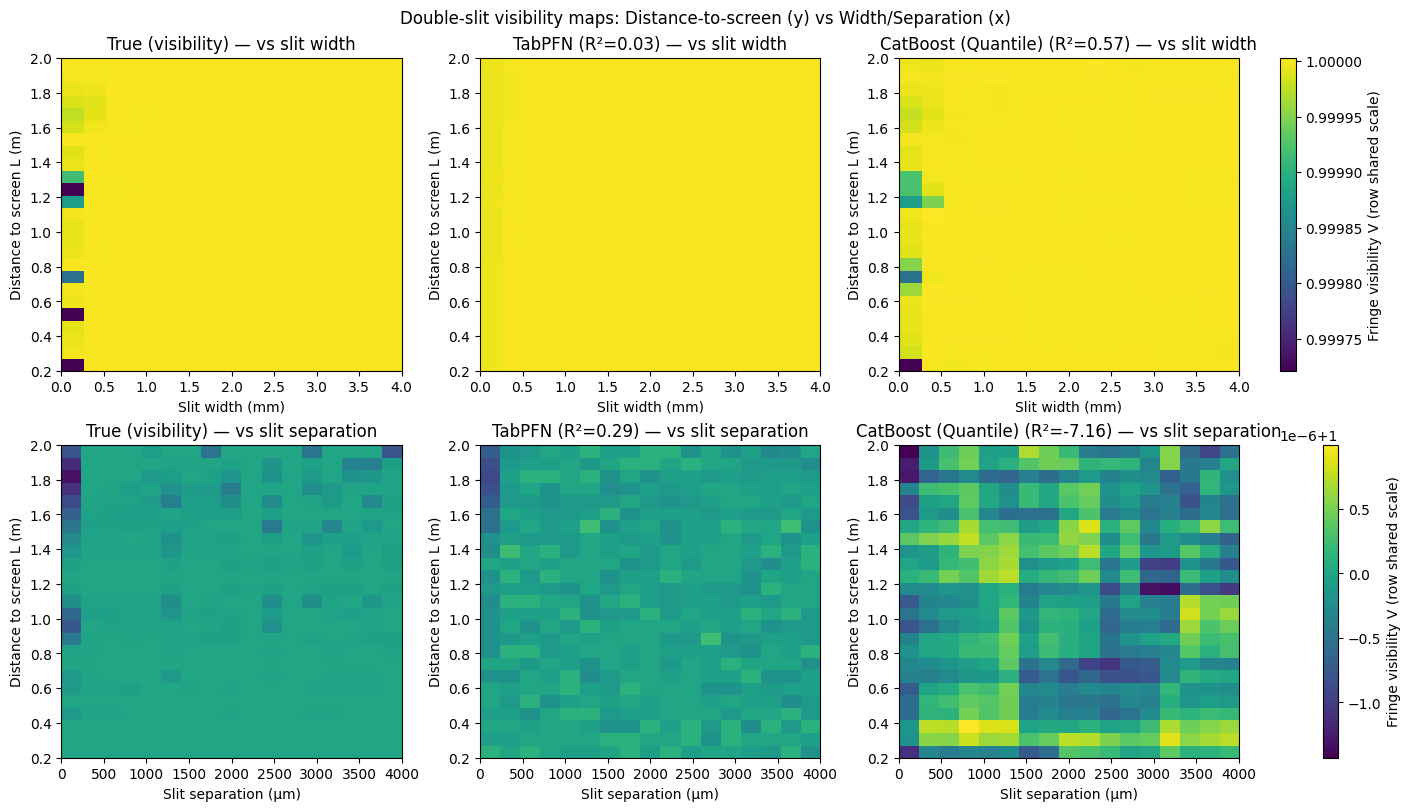

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor
from tabpfn import TabPFNRegressor
from matplotlib.colors import Normalize

# -----------------------------
# Physics: intensity calculation
# -----------------------------
def sinc_safe(z):
    out = np.ones_like(z)
    nz = z != 0
    out[nz] = np.sin(z[nz]) / z[nz]
    return out

# I(x; a, d, lambda, L) = I0 * [sinc(π a x / (λ L))]^2 * cos^2(π d x / (λ L))
def double_slit_intensity(x, a, d, lam, L, I0=1.0):
    beta  = np.pi * a * x / (lam * L)
    delta = np.pi * d * x / (lam * L)
    return I0 * (sinc_safe(beta) ** 2) * (np.cos(delta) ** 2)

def fringe_visibility_from_profile(Ix):
    Imax = np.max(Ix)
    Imin = np.min(Ix)
    denom = (Imax + Imin)
    if denom <= 1e-12:
        return 0.0
    return float((Imax - Imin) / denom)

# -----------------------------
# Simulation grid
# -----------------------------
LAM = 532e-9                     # wavelength (m), 532 nm
x = np.linspace(-8e-3, 8e-3, 801)  # screen coordinate (m) ±8 mm

# y-axis (rows): distance to screen (m)
L_values = np.linspace(0.2, 2.0, 25)

# Row 1 (width axis)
width_mm = np.array([0.00, 0.10, 0.20, 0.25, 0.35, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00, 2.50, 3.00, 3.50, 4.00])
width_m  = width_mm * 1e-3
D_FIXED  = 1.0e-3   # fixed separation = 1 mm

# Row 2 (separation axis)
sep_um = np.array([0, 100, 200, 300, 400, 500, 600, 800, 1000, 1250, 1500, 1750, 2000, 2500, 3000, 3500, 4000])
sep_m  = sep_um * 1e-6
A_FIXED = 500e-6    # fixed width = 0.5 mm

# -----------------------------
# Build "true" visibility maps
# -----------------------------
vis_map_A = np.zeros((L_values.size, width_m.size))
for iL, L in enumerate(L_values):
    for jw, a in enumerate(width_m):
        Iprofile = double_slit_intensity(x, a=a, d=D_FIXED, lam=LAM, L=L)
        vis_map_A[iL, jw] = fringe_visibility_from_profile(Iprofile)

vis_map_B = np.zeros((L_values.size, sep_m.size))
for iL, L in enumerate(L_values):
    for jd, d in enumerate(sep_m):
        Iprofile = double_slit_intensity(x, a=A_FIXED, d=d, lam=LAM, L=L)
        vis_map_B[iL, jd] = fringe_visibility_from_profile(Iprofile)

# -----------------------------
# Tabular data for ML: predict V from [L, a, d]
# -----------------------------
features, targets = [], []

# Row 1 sweep (vary width, fix d)
for iL, L in enumerate(L_values):
    for jw, a in enumerate(width_m):
        features.append([L, a, D_FIXED])
        targets.append(vis_map_A[iL, jw])

# Row 2 sweep (vary separation, fix a)
for iL, L in enumerate(L_values):
    for jd, d in enumerate(sep_m):
        features.append([L, A_FIXED, d])
        targets.append(vis_map_B[iL, jd])

X = np.array(features)   # [L, a, d] in meters
y = np.array(targets)    # visibility in [0,1]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=42)

# TabPFN prefers standardized inputs
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)

# -----------------------------
# Models
# -----------------------------
# TabPFN Regressor (NOTE: no classifier-only kwargs)
tabpfn = TabPFNRegressor()
tabpfn.fit(X_train_s, y_train)

# CatBoost Quantile (median)
cat_median = CatBoostRegressor(
    loss_function="Quantile:alpha=0.5",
    iterations=800,
    depth=6,
    learning_rate=0.05,
    verbose=False
)
cat_median.fit(X_train, y_train)  # CatBoost handles raw scale fine

# -----------------------------
# Rebuild predicted maps
# -----------------------------
def rebuild_map(model, use_scaler, L_vals, X_axis_vals, fixed_other, vary='width'):
    """
    vary = 'width'  -> X-axis is slit width (a), fix d
    vary = 'sep'    -> X-axis is slit separation (d), fix a
    Returns Z with shape [len(L_vals), len(X_axis_vals)]
    """
    Z = np.zeros((len(L_vals), len(X_axis_vals)))
    for iL, L in enumerate(L_vals):
        if vary == 'width':
            a = X_axis_vals
            d = np.full_like(a, fixed_other)
            feats = np.stack([np.full_like(a, L), a, d], axis=1)
        else:
            d = X_axis_vals
            a = np.full_like(d, fixed_other)
            feats = np.stack([np.full_like(d, L), a, d], axis=1)
        if use_scaler:
            Z[iL] = model.predict(scaler.transform(feats))
        else:
            Z[iL] = model.predict(feats)
    return Z

tabpfn_map_A = rebuild_map(tabpfn, True,  L_values, width_m, D_FIXED, vary='width')
tabpfn_map_B = rebuild_map(tabpfn, True,  L_values, sep_m,   A_FIXED, vary='sep')
cat_map_A    = rebuild_map(cat_median, False, L_values, width_m, D_FIXED, vary='width')
cat_map_B    = rebuild_map(cat_median, False, L_values, sep_m,   A_FIXED, vary='sep')

# R² against the true maps
r2_tabpfn_A = r2_score(vis_map_A.ravel(), tabpfn_map_A.ravel())
r2_tabpfn_B = r2_score(vis_map_B.ravel(), tabpfn_map_B.ravel())
r2_cat_A    = r2_score(vis_map_A.ravel(), cat_map_A.ravel())
r2_cat_B    = r2_score(vis_map_B.ravel(), cat_map_B.ravel())

# -----------------------------
# Plot: 2 rows × 3 columns
# Same color scale per row
# -----------------------------
fig, axs = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

# Row 1 (width)
vmin_A = min(vis_map_A.min(), tabpfn_map_A.min(), cat_map_A.min())
vmax_A = max(vis_map_A.max(), tabpfn_map_A.max(), cat_map_A.max())
norm_A = Normalize(vmin=vmin_A, vmax=vmax_A)

im0 = axs[0,0].imshow(vis_map_A, aspect='auto', origin='lower',
                      extent=[width_mm[0], width_mm[-1], L_values[0], L_values[-1]],
                      norm=norm_A, cmap='viridis')
axs[0,0].set_title('True (visibility) — vs slit width')
axs[0,0].set_xlabel('Slit width (mm)')
axs[0,0].set_ylabel('Distance to screen L (m)')

im1 = axs[0,1].imshow(tabpfn_map_A, aspect='auto', origin='lower',
                      extent=[width_mm[0], width_mm[-1], L_values[0], L_values[-1]],
                      norm=norm_A, cmap='viridis')
axs[0,1].set_title(f'TabPFN (R²={r2_tabpfn_A:.2f}) — vs slit width')
axs[0,1].set_xlabel('Slit width (mm)')
axs[0,1].set_ylabel('Distance to screen L (m)')

im2 = axs[0,2].imshow(cat_map_A, aspect='auto', origin='lower',
                      extent=[width_mm[0], width_mm[-1], L_values[0], L_values[-1]],
                      norm=norm_A, cmap='viridis')
axs[0,2].set_title(f'CatBoost (Quantile) (R²={r2_cat_A:.2f}) — vs slit width')
axs[0,2].set_xlabel('Slit width (mm)')
axs[0,2].set_ylabel('Distance to screen L (m)')

# Single colorbar for row 1
cbarA = fig.colorbar(im0, ax=axs[0,:], orientation='vertical', fraction=0.02, pad=0.02)
cbarA.set_label('Fringe visibility V (row shared scale)')

# Row 2 (separation)
vmin_B = min(vis_map_B.min(), tabpfn_map_B.min(), cat_map_B.min())
vmax_B = max(vis_map_B.max(), tabpfn_map_B.max(), cat_map_B.max())
norm_B = Normalize(vmin=vmin_B, vmax=vmax_B)

im3 = axs[1,0].imshow(vis_map_B, aspect='auto', origin='lower',
                      extent=[sep_um[0], sep_um[-1], L_values[0], L_values[-1]],
                      norm=norm_B, cmap='viridis')
axs[1,0].set_title('True (visibility) — vs slit separation')
axs[1,0].set_xlabel('Slit separation (µm)')
axs[1,0].set_ylabel('Distance to screen L (m)')

im4 = axs[1,1].imshow(tabpfn_map_B, aspect='auto', origin='lower',
                      extent=[sep_um[0], sep_um[-1], L_values[0], L_values[-1]],
                      norm=norm_B, cmap='viridis')
axs[1,1].set_title(f'TabPFN (R²={r2_tabpfn_B:.2f}) — vs slit separation')
axs[1,1].set_xlabel('Slit separation (µm)')
axs[1,1].set_ylabel('Distance to screen L (m)')

im5 = axs[1,2].imshow(cat_map_B, aspect='auto', origin='lower',
                      extent=[sep_um[0], sep_um[-1], L_values[0], L_values[-1]],
                      norm=norm_B, cmap='viridis')
axs[1,2].set_title(f'CatBoost (Quantile) (R²={r2_cat_B:.2f}) — vs slit separation')
axs[1,2].set_xlabel('Slit separation (µm)')
axs[1,2].set_ylabel('Distance to screen L (m)')

# Single colorbar for row 2
cbarB = fig.colorbar(im3, ax=axs[1,:], orientation='vertical', fraction=0.02, pad=0.02)
cbarB.set_label('Fringe visibility V (row shared scale)')

fig.suptitle('Double-slit visibility maps: Distance-to-screen (y) vs Width/Separation (x)', fontsize=12)
plt.show()

From the heatmap plottings, it is actually evident that in the first case - that of the Distance to screen vs. Slit width, CatBoost performs slightly better in the sense that it captures the variation on the lower slit width part.
For the Distance to screen vs. Slit separation, TabPFN seems to perform slightly better, as CatBoost overestimates a lot of the values and provides greater variability in the results than the actual true function.

Again, I have not managed to recreate the results from the paper, due to the lack of understand of the physics background of the experiment and possibly, the actual model set-ups used.

I proceed to build the code for producing Position on screen graphs below:

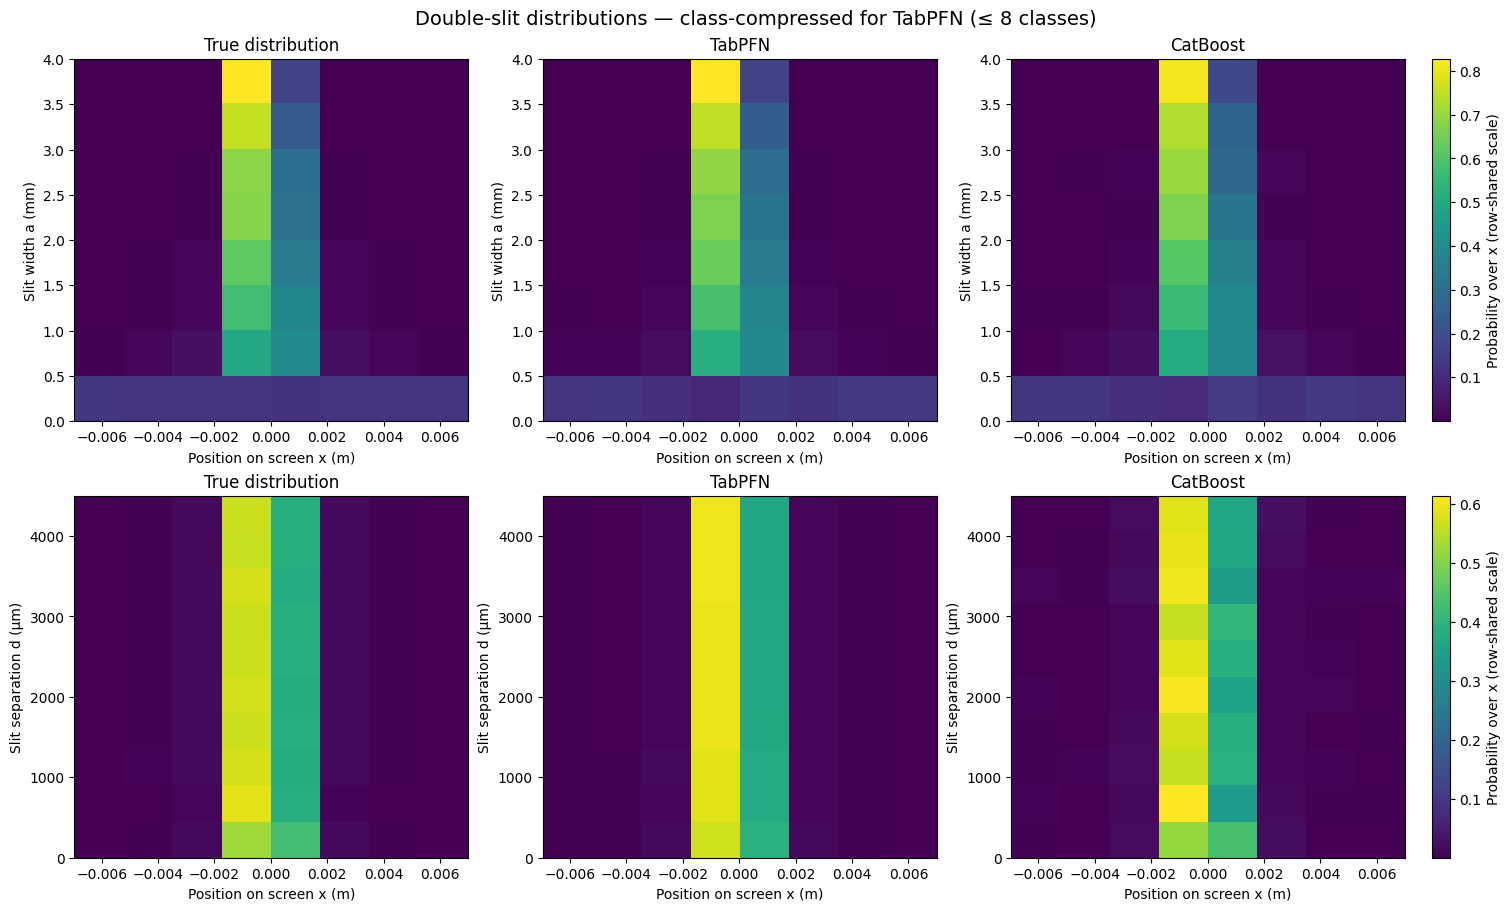

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from tabpfn import TabPFNClassifier
from catboost import CatBoostClassifier

# ----------------------------
# Physics: intensity formula
# ----------------------------
def intensity_profile(x, a, d, L, lam):
    """
    I(x) ∝ sinc^2(π a x / (λ L)) * cos^2(π d x / (λ L))
    """
    eps = 1e-16
    arg = np.pi * x / (lam * (L + eps))
    beta = a * arg
    alpha = d * arg
    sinc2 = (np.sinc(beta / np.pi)) ** 2
    cos2  = (np.cos(alpha)) ** 2
    return sinc2 * cos2

def probs_over_bins(x_edges, I_centers):
    """
    Convert intensity at bin centers to a probability for each bin using the midpoint rule.
    x_edges: array of length N+1
    I_centers: array of length N (aligned with the centers of those bins)
    """
    dx = np.diff(x_edges)              # N
    w = I_centers * dx                 # N
    total = w.sum()
    if total <= 0:
        return np.ones_like(w) / len(w)
    return w / total

# --------------------------------
# Simulation config (fixed values)
# --------------------------------
RNG = np.random.default_rng(7)

LAM = 550e-9                      # 550 nm
X_MIN, X_MAX = -8e-3,  8e-3       # screen window ±8 mm
N_BINS_RAW = 201                  # raw number of position bins (can be large)

# >>> Reduce classes so TabPFN won't error <<<
MAX_TABPFN_CLASSES = 8           # SAFE: lower than your failing 32 (use 8 if needed)

PHOTONS_PER_COND = 120            # photons per (L, a, d) condition

x_edges_raw   = np.linspace(X_MIN, X_MAX, N_BINS_RAW + 1)   # length 202
x_centers_raw = 0.5 * (x_edges_raw[:-1] + x_edges_raw[1:])  # length 201

# Distances to screen (m)
L_values = np.linspace(0.2, 2.0, 16)

# Row 1 (vary width)
width_values_m = np.array([0.00, 0.25, 0.50, 0.75, 1.00, 1.25, 2.50, 4.00]) * 1e-3
d_fixed = 1.0e-3  # 1 mm

# Row 2 (vary separation)
sep_values_m = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]) * 1e-3
a_fixed = 0.50e-3  # 0.5 mm

# ------------------------------
# Build tabular dataset (X, y_raw)
# ------------------------------
def simulate_dataset():
    rows_X = []
    rows_y = []
    # Row 1 (vary width): features = [L, a, d_fixed]
    for a in width_values_m:
        for L in L_values:
            # intensity at RAW centers
            I_raw = intensity_profile(x_centers_raw, a=a, d=d_fixed, L=L, lam=LAM)
            p_bins = probs_over_bins(x_edges_raw, I_raw)   # midpoint rule
            counts = RNG.multinomial(PHOTONS_PER_COND, p_bins)
            for cls_bin, cnt in enumerate(counts):
                if cnt > 0:
                    rows_X.append(np.tile([L, a, d_fixed], (cnt, 1)))
                    rows_y.append(np.full(cnt, cls_bin, dtype=int))
    # Row 2 (vary separation): features = [L, a_fixed, d]
    for d in sep_values_m:
        for L in L_values:
            I_raw = intensity_profile(x_centers_raw, a=a_fixed, d=d, L=L, lam=LAM)
            p_bins = probs_over_bins(x_edges_raw, I_raw)
            counts = RNG.multinomial(PHOTONS_PER_COND, p_bins)
            for cls_bin, cnt in enumerate(counts):
                if cnt > 0:
                    rows_X.append(np.tile([L, a_fixed, d], (cnt, 1)))
                    rows_y.append(np.full(cnt, cls_bin, dtype=int))
    X = np.vstack(rows_X)       # [L, a, d]
    y = np.concatenate(rows_y)  # class index (raw) ∈ [0, N_BINS_RAW-1]
    return X, y

# --- compress classes to ≤ max_classes, preserving order/contiguity ---
def compress_classes(y, max_classes):
    y = np.asarray(y)
    labels, inverse = np.unique(y, return_inverse=True)  # labels sorted ascending
    k = len(labels)
    if k <= max_classes:
        return y.astype(int)
    ranks = np.arange(k)
    bucket = (ranks * max_classes) // k  # integer floor 0..max_classes-1
    new_y = bucket[inverse]
    return new_y.astype(int)

# --- ensure every class has at least 'min_count' samples ---
def enforce_min_count(X, y, n_classes, min_count=2, rng=RNG):
    counts = np.bincount(y, minlength=n_classes)
    need_classes = np.where(counts < min_count)[0]
    if need_classes.size == 0:
        return X, y
    X_add = []
    y_add = []
    for c in need_classes:
        idx = np.where(y == c)[0]
        if idx.size == 0:
            # borrow neighbor or random sample and relabel to class c
            neighbors = [c-1, c+1]
            found = None
            for nb in neighbors:
                if 0 <= nb < n_classes:
                    nb_idx = np.where(y == nb)[0]
                    if nb_idx.size > 0:
                        found = nb_idx[RNG.integers(nb_idx.size)]
                        break
            if found is None:
                found = RNG.integers(len(y))
            X_add.append(X[found:found+1])
            y_add.append(np.array([c], dtype=int))
            idx = np.array([found])
        while idx.size < min_count:
            pick = idx[RNG.integers(idx.size)]
            X_add.append(X[pick:pick+1])
            y_add.append(np.array([c], dtype=int))
            idx = np.append(idx, pick)
    if X_add:
        X = np.vstack([X] + X_add)
        y = np.concatenate([y] + y_add)
    return X, y

# --- stratified cap to <= max_samples ---
def stratified_cap(X, y, max_samples, rng_seed=42):
    if len(y) <= max_samples:
        return X, y
    sss = StratifiedShuffleSplit(n_splits=1, train_size=max_samples, random_state=rng_seed)
    keep_idx, _ = next(sss.split(X, y))
    return X[keep_idx], y[keep_idx]

TABPFN_MAX_SAMPLES = 9000  # stay under 10k

# 1) Simulate
X_all, y_all_raw = simulate_dataset()

# 2) Compress classes to ≤ MAX_TABPFN_CLASSES
y_all = compress_classes(y_all_raw, MAX_TABPFN_CLASSES)
N_CLASSES = int(np.max(y_all) + 1)

# 3) FIX MIN-COUNT **before** first stratified op
X_all, y_all = enforce_min_count(X_all, y_all, N_CLASSES, min_count=2, rng=RNG)

# 4) Cap to TabPFN limit (stratified)
X_all, y_all = stratified_cap(X_all, y_all, TABPFN_MAX_SAMPLES, rng_seed=123)

# 5) FIX MIN-COUNT **again** (cap can create new singletons)
X_all, y_all = enforce_min_count(X_all, y_all, N_CLASSES, min_count=2, rng=RNG)

# ----------------------
# Train the classifiers
# ----------------------
X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)

# TabPFN (classifier) – now ≤ 16 classes
tabpfn = TabPFNClassifier()
tabpfn.fit(X_train_s, y_train)

# CatBoost (classifier)
cat = CatBoostClassifier(
    iterations=600,
    learning_rate=0.1,
    depth=6,
    loss_function="MultiClass",
    verbose=False,
    random_seed=7,
)
cat.fit(X_train, y_train)

# ----------------------
# Grids for plotting (same row-wise shared scales)
# ----------------------
def predict_grid(model, scaler_or_none, y_vals, vary="width"):
    mats = []
    for y_val in y_vals:
        row_probs = []
        for L in L_values:
            if vary == "width":
                a, d = y_val, d_fixed
            else:
                a, d = a_fixed, y_val
            Xq = np.array([[L, a, d]])
            if scaler_or_none is not None:
                p = model.predict_proba(scaler_or_none.transform(Xq))[0]
            else:
                p = model.predict_proba(Xq)[0]
            row_probs.append(p)
        mats.append(np.mean(np.vstack(row_probs), axis=0))  # average over L
    return np.vstack(mats)

def true_grid(y_vals, vary="width"):
    # True grid must match COMPRESSED class space (≤ MAX_TABPFN_CLASSES)
    mats = []
    # compression map from raw bin ids to compressed ids
    raw_ids = np.arange(N_BINS_RAW)
    comp_ids = compress_classes(raw_ids, MAX_TABPFN_CLASSES)
    for y_val in y_vals:
        row_probs_over_L = []
        for L in L_values:
            if vary == "width":
                a, d = y_val, d_fixed
            else:
                a, d = a_fixed, y_val
            I_raw = intensity_profile(x_centers_raw, a=a, d=d, L=L, lam=LAM)
            p_raw = probs_over_bins(x_edges_raw, I_raw)
            comp_probs = np.zeros(MAX_TABPFN_CLASSES, dtype=float)
            for rid, prob in enumerate(p_raw):
                comp_probs[comp_ids[rid]] += prob
            row_probs_over_L.append(comp_probs)
        mats.append(np.mean(np.vstack(row_probs_over_L), axis=0))
    return np.vstack(mats)

# Panels to plot
true_width_grid   = true_grid(width_values_m, vary="width")
tabpfn_width_grid = predict_grid(tabpfn, scaler, width_values_m, vary="width")
cat_width_grid    = predict_grid(cat, None,     width_values_m, vary="width")

true_sep_grid   = true_grid(sep_values_m, vary="sep")
tabpfn_sep_grid = predict_grid(tabpfn, scaler, sep_values_m, vary="sep")
cat_sep_grid    = predict_grid(cat, None,     sep_values_m, vary="sep")

# Shared color scales per row
vmin_row1 = min(true_width_grid.min(), tabpfn_width_grid.min(), cat_width_grid.min())
vmax_row1 = max(true_width_grid.max(), tabpfn_width_grid.max(), cat_width_grid.max())
vmin_row2 = min(true_sep_grid.min(), tabpfn_sep_grid.min(), cat_sep_grid.min())
vmax_row2 = max(true_sep_grid.max(), tabpfn_sep_grid.max(), cat_sep_grid.max())

# compressed x-axis positions for display
raw_ids = np.arange(N_BINS_RAW)
comp_ids = compress_classes(raw_ids, MAX_TABPFN_CLASSES)
x_comp = np.array([x_centers_raw[comp_ids == k].mean() for k in range(MAX_TABPFN_CLASSES)])

# ----------------------
# Plot 2×3 panels
# ----------------------
fig, axs = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

def show(ax, grid, title, row=1):
    if row == 1:
        im = ax.imshow(
            grid,
            aspect="auto",
            origin="lower",
            extent=[x_comp[0], x_comp[-1],
                    (width_values_m[0]*1e3), (width_values_m[-1]*1e3)],
            vmin=vmin_row1, vmax=vmax_row1, cmap="viridis",
        )
        ax.set_ylabel("Slit width a (mm)")
    else:
        im = ax.imshow(
            grid,
            aspect="auto",
            origin="lower",
            extent=[x_comp[0], x_comp[-1],
                    (sep_values_m[0]*1e6), (sep_values_m[-1]*1e6)],
            vmin=vmin_row2, vmax=vmax_row2, cmap="viridis",
        )
        ax.set_ylabel("Slit separation d (µm)")
    ax.set_xlabel("Position on screen x (m)")
    ax.set_title(title)
    return im

im1 = show(axs[0,0], true_width_grid,   "True distribution", row=1)
im2 = show(axs[0,1], tabpfn_width_grid, "TabPFN",            row=1)
im3 = show(axs[0,2], cat_width_grid,    "CatBoost",          row=1)

im4 = show(axs[1,0], true_sep_grid,     "True distribution", row=2)
im5 = show(axs[1,1], tabpfn_sep_grid,   "TabPFN",            row=2)
im6 = show(axs[1,2], cat_sep_grid,      "CatBoost",          row=2)

cbar1 = fig.colorbar(im1, ax=axs[0,:], orientation="vertical", fraction=0.025, pad=0.02)
cbar1.set_label("Probability over x (row-shared scale)")

cbar2 = fig.colorbar(im4, ax=axs[1,:], orientation="vertical", fraction=0.025, pad=0.02)
cbar2.set_label("Probability over x (row-shared scale)")

fig.suptitle(f"Double-slit distributions — class-compressed for TabPFN (≤ {MAX_TABPFN_CLASSES} classes)", fontsize=14)
plt.show()

Here, CatBoost and TabPFN perform somewhat on par, with TabPFN having slightly better results for the second case - that of Slit separation vs. Position on screen, as the variability in values is again overestimated by CatBoost.

### Quantitative analysis on benchmarks Fig 4





On Figure 4 TabPFN is compared to test benchmarks of datasets with up to $10,000$ samples and $500$ features. I use the datasets from the paper (see Appendix for their OpenML IDs), and compute:

- for (a) the average performance of the default and the tuned versions of TabPFN and baselines. See Appendix for tuning options and parameters used in the paper for those.
- for (b) the Wilcoxon P comparison between CatBoost and TabPFN
- for (c) the impact of hyperparameter tuning for the considered methods, where the x-axis shows the average time required to fit and predict with the algorithm

As a side note, I have used much less training time and relaxed the training parameters, due to hardware and time constraints. Thus, my reproduction of these graphs will only be limited and as a proof of concept.

**Adjustable params and dataset IDs**

In [5]:
# Adjustable parameters
N_REPETITIONS = 3  # Number of repetitions with different random seeds
HPO_TIME_PER_MODEL = 300  # Total HPO time per model in seconds (across all datasets)
TEST_SIZE = 0.2  # Train-test split ratio

# Dataset IDs from the paper
CLASSIFICATION_DATASETS = [
    41156, 40981, 1464, 40975, 40701, 23, 31, 40670, 188, 1475, 4538, 41143,
    1067, 3, 41144, 12, 1487, 1049, 41145, 1489, 1494, 40900, 40984,
    40982, 41146, 54, 40983, 40498, 181
]


REGRESSION_DATASETS = [
    42726, 44957, 44958, 531, 44994, 42727, 44959, 44978, 44960, 44965,
    44973, 42563, 44980, 42570, 43071, 41021, 44981, 44970, 550, 41980,
    546, 541, 507, 44967, 505, 422, 42730, 416
]

print(f"Classification datasets: {len(CLASSIFICATION_DATASETS)}")
print(f"Regression datasets: {len(REGRESSION_DATASETS)}")

Classification datasets: 29
Regression datasets: 28


**Hyperparam search spaces**

In [6]:
def get_search_space_classification(trial, model_name):
    """Get hyperparameter search space for classification models"""
    
    if model_name == 'Linear':
        return {
            'C': trial.suggest_float('C', 1e-5, 1e5, log=True),
            'max_iter': 1000,
            'random_state': RANDOM_STATE
        }
    
    elif model_name == 'MLP':
        n_layers = trial.suggest_int('n_layers', 1, 3)
        hidden_layer_sizes = tuple([trial.suggest_int(f'n_units_l{i}', 32, 512) for i in range(n_layers)])
        return {
            'hidden_layer_sizes': hidden_layer_sizes,
            'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
            'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
            'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
            'max_iter': 1000,
            'random_state': RANDOM_STATE,
            'early_stopping': True
        }
    
    elif model_name == 'SVM':
        return {
            'C': trial.suggest_float('C', 1e-3, 1e3, log=True),
            'gamma': trial.suggest_float('gamma', 1e-4, 1e1, log=True),
            'kernel': 'rbf',
            'probability': True
        }
    
    elif model_name == 'RF':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': RANDOM_STATE
        }
    
    elif model_name == 'LGBM':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': RANDOM_STATE,
            'verbose': -1
        }
    
    elif model_name == 'CB':
        return {
            'iterations': trial.suggest_int('iterations', 50, 500),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'depth': trial.suggest_int('depth', 3, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
            'random_state': RANDOM_STATE,
            'verbose': False
        }
    
    elif model_name == 'XGB':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': RANDOM_STATE
        }
    
    elif model_name == 'TabPFN':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 1, 32),
            'device': 'cuda',  # Change to 'cuda' if GPU available
            'random_state': RANDOM_STATE
        }

def get_search_space_regression(trial, model_name):
    """Get hyperparameter search space for regression models"""
    
    if model_name == 'Linear':
        return {
            'alpha': trial.suggest_float('alpha', 1e-5, 1e5, log=True),
            'random_state': RANDOM_STATE
        }
    
    elif model_name == 'MLP':
        n_layers = trial.suggest_int('n_layers', 1, 3)
        hidden_layer_sizes = tuple([trial.suggest_int(f'n_units_l{i}', 32, 512) for i in range(n_layers)])
        return {
            'hidden_layer_sizes': hidden_layer_sizes,
            'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
            'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
            'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
            'max_iter': 1000,
            'random_state': RANDOM_STATE,
            'early_stopping': True
        }
    
    elif model_name == 'SVM':
        return {
            'C': trial.suggest_float('C', 1e-3, 1e3, log=True),
            'gamma': trial.suggest_float('gamma', 1e-4, 1e1, log=True),
            'kernel': 'rbf',
            }
    
    elif model_name == 'RF':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': RANDOM_STATE
        }
    
    elif model_name == 'LGBM':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': RANDOM_STATE,
            'verbose': -1
        }
    
    elif model_name == 'CB':
        return {
            'iterations': trial.suggest_int('iterations', 50, 500),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'depth': trial.suggest_int('depth', 3, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
            'random_state': RANDOM_STATE,
            'verbose': False
        }
    
    elif model_name == 'XGB':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': RANDOM_STATE
        }
    
    elif model_name == 'TabPFN':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 1, 32),
            'device': 'cuda',  # Change to 'cuda' if GPU available
            'random_state': RANDOM_STATE
        }

def get_default_params_classification(model_name):
    """Get default hyperparameters for classification models"""
    
    defaults = {
        'Linear': {'C': 1.0, 'max_iter': 1000, 'random_state': RANDOM_STATE},
        'MLP': {'hidden_layer_sizes': (100,), 'max_iter': 1000, 'random_state': RANDOM_STATE, 'early_stopping': True},
        'SVM': {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf', 'probability': True},
        'RF': {'n_estimators': 100, 'random_state': RANDOM_STATE},
        'LGBM': {'n_estimators': 100, 'random_state': RANDOM_STATE, 'verbose': -1},
        'CB': {'iterations': 100, 'random_state': RANDOM_STATE, 'verbose': False},
        'XGB': {'n_estimators': 100, 'random_state': RANDOM_STATE},
        'TabPFN': {'n_estimators': 16, 'device': 'cuda', 'random_state': RANDOM_STATE}
    }
    return defaults[model_name]

def get_default_params_regression(model_name):
    """Get default hyperparameters for regression models"""
    
    defaults = {
        'Linear': {'alpha': 1.0, 'random_state': RANDOM_STATE},
        'MLP': {'hidden_layer_sizes': (100,), 'max_iter': 1000, 'random_state': RANDOM_STATE, 'early_stopping': True},
        'SVM': {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'},
        'RF': {'n_estimators': 100, 'random_state': RANDOM_STATE},
        'LGBM': {'n_estimators': 100, 'random_state': RANDOM_STATE, 'verbose': -1},
        'CB': {'iterations': 100, 'random_state': RANDOM_STATE, 'verbose': False},
        'XGB': {'n_estimators': 100, 'random_state': RANDOM_STATE},
        'TabPFN': {'n_estimators': 16, 'device': 'cuda', 'random_state': RANDOM_STATE}
    }
    return defaults[model_name]

**Model Initialization Functions**

In [7]:
def get_model_classification(model_name, params):
    """Initialize classification model with given parameters"""
    
    if model_name == 'Linear':
        return LogisticRegression(**params)
    elif model_name == 'MLP':
        return MLPClassifier(**params)
    elif model_name == 'SVM':
        return SVC(**params)
    elif model_name == 'RF':
        return RandomForestClassifier(**params)
    elif model_name == 'LGBM':
        return LGBMClassifier(**params)
    elif model_name == 'CB':
        return CatBoostClassifier(**params)
    elif model_name == 'XGB':
        return XGBClassifier(**params)
    elif model_name == 'TabPFN':
        return TabPFNClassifier(**params)

def get_model_regression(model_name, params):
    """Initialize regression model with given parameters"""
    
    if model_name == 'Linear':
        return Ridge(**params)
    elif model_name == 'MLP':
        return MLPRegressor(**params)
    elif model_name == 'SVM':
        return SVR(**params)
    elif model_name == 'RF':
        return RandomForestRegressor(**params)
    elif model_name == 'LGBM':
        return LGBMRegressor(**params)
    elif model_name == 'CB':
        return CatBoostRegressor(**params)
    elif model_name == 'XGB':
        return XGBRegressor(**params)
    elif model_name == 'TabPFN':
        return TabPFNRegressor(**params)

**Data Loading and preprocessing**

In [8]:
def load_dataset(dataset_id, task_type='classification'):
    """Load and preprocess dataset from OpenML"""
    try:
        dataset = openml.datasets.get_dataset(dataset_id)
        X, y, categorical_indicator, attribute_names = dataset.get_data(
            dataset_format="dataframe", target=dataset.default_target_attribute
        )
        
        # Handle missing values
        if X.isnull().any().any():
            # For numerical columns, fill with median
            for col in X.select_dtypes(include=[np.number]).columns:
                X[col].fillna(X[col].median(), inplace=True)
            # For categorical columns, fill with mode
            for col in X.select_dtypes(include=['object', 'category']).columns:
                X[col].fillna(X[col].mode()[0] if not X[col].mode().empty else 'missing', inplace=True)
        
        # Encode categorical features
        for col in X.select_dtypes(include=['object', 'category']).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
        
        # Encode target for classification
        if task_type == 'classification':
            if y.dtype == 'object' or y.dtype.name == 'category':
                le = LabelEncoder()
                y = le.fit_transform(y.astype(str))
        
        # Handle missing values in target
        if pd.isna(y).any():
            valid_indices = ~pd.isna(y)
            X = X[valid_indices]
            y = y[valid_indices]
        
        # Convert to numpy arrays
        X = X.values.astype(np.float32)
        y = y.values if isinstance(y, pd.Series) else y
        
        # Check for TabPFN constraints (max 10000 samples, max 100 features for classification)
        n_samples, n_features = X.shape
        tabpfn_compatible = True
        if task_type == 'classification':
            tabpfn_compatible = n_samples <= 10000 and n_features <= 100
        else:
            tabpfn_compatible = n_samples <= 10000
        
        return X, y, tabpfn_compatible, dataset.name
    
    except Exception as e:
        print(f"Error loading dataset {dataset_id}: {str(e)}")
        return None, None, False, None

**Hyperparameter optimization**

In [9]:
def optimize_hyperparameters(X_train, y_train, model_name, task_type, time_budget):
    """Optimize hyperparameters using Optuna"""
    
    def objective(trial):
        try:
            # Get hyperparameters
            if task_type == 'classification':
                params = get_search_space_classification(trial, model_name)
                model = get_model_classification(model_name, params)
            else:
                params = get_search_space_regression(trial, model_name)
                model = get_model_regression(model_name, params)
            
            # Use a smaller validation split for HPO
            X_tr, X_val, y_tr, y_val = train_test_split(
                X_train, y_train, test_size=0.2, random_state=RANDOM_STATE
            )
            
            # Fit model
            model.fit(X_tr, y_tr)
            
            # Evaluate
            if task_type == 'classification':
                y_pred = model.predict(X_val)
                score = accuracy_score(y_val, y_pred)
            else:
                y_pred = model.predict(X_val)
                score = -mean_squared_error(y_val, y_pred)  # Negative because we maximize
            
            return score
        
        except Exception as e:
            return float('-inf')
    
    # Create study
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, timeout=time_budget)
    
    # Reconstruct the proper parameters from the best trial
    # This ensures that complex parameters like hidden_layer_sizes are properly constructed
    if task_type == 'classification':
        best_params = get_search_space_classification(study.best_trial, model_name)
    else:
        best_params = get_search_space_regression(study.best_trial, model_name)
    
    return best_params

**Model evaluation**

In [10]:
def evaluate_model(model, X_test, y_test, task_type):
    """Evaluate model and return metrics"""
    
    if task_type == 'classification':
        y_pred = model.predict(X_test)
        
        # Calculate accuracy
        acc = accuracy_score(y_test, y_pred)
        
        # Calculate ROC AUC
        try:
            if hasattr(model, 'predict_proba'):
                y_pred_proba = model.predict_proba(X_test)
                n_classes = len(np.unique(y_test))
                
                if n_classes == 2:
                    # Binary classification
                    roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
                else:
                    # Multi-class classification with weighted average
                    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
            else:
                roc_auc = np.nan
        except:
            roc_auc = np.nan
        
        return {'roc_auc': roc_auc, 'accuracy': acc}
    
    else:  # regression
        y_pred = model.predict(X_test)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        return {'rmse': rmse, 'r2': r2}

**Main Benchmark Function**

In [11]:
def run_benchmark(dataset_ids, task_type, model_names):
    """Run benchmark for all models on all datasets"""
    
    results = []
    
    # Calculate time budget per dataset per model
    n_datasets = len(dataset_ids)
    time_per_dataset_per_model = HPO_TIME_PER_MODEL / n_datasets
    
    print(f"\n{'='*80}")
    print(f"Running {task_type.upper()} benchmark")
    print(f"Datasets: {n_datasets}")
    print(f"Models: {len(model_names)}")
    print(f"Repetitions: {N_REPETITIONS}")
    print(f"HPO time per model per dataset: {time_per_dataset_per_model:.2f}s")
    print(f"{'='*80}\n")
    
    for dataset_id in dataset_ids:
        print(f"\nProcessing dataset {dataset_id}...")
        
        # Load dataset
        X, y, tabpfn_compatible, dataset_name = load_dataset(dataset_id, task_type)
        
        if X is None:
            print(f"  Skipping dataset {dataset_id} due to loading error")
            continue
        
        print(f"  Dataset: {dataset_name} (ID: {dataset_id})")
        print(f"  Shape: {X.shape}, TabPFN compatible: {tabpfn_compatible}")
        
        # Run multiple repetitions
        for rep in range(N_REPETITIONS):
            seed = RANDOM_STATE + rep
            print(f"  Repetition {rep+1}/{N_REPETITIONS} (seed: {seed})")
            
            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=TEST_SIZE, random_state=seed
            )
            
            # Scale features
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            for model_name in model_names:
                # Skip TabPFN if not compatible
                if model_name == 'TabPFN' and not tabpfn_compatible:
                    print(f"    {model_name}: Skipped (incompatible dataset)")
                    continue
                
                try:

                
                    # Skip TabPFN for regression if it has too many unique targets

                
                    if model_name == 'TabPFN' and task_type == 'regression':

                
                        n_unique_targets = len(np.unique(y_train))

                
                        if n_unique_targets > 10:

                
                            print(f"    {model_name}: Skipped (target has {n_unique_targets} unique values)")

                
                            continue

                
                    

                
                    # ===== NON-TUNED MODEL =====
                    if task_type == 'classification':
                        default_params = get_default_params_classification(model_name)
                        model_default = get_model_classification(model_name, default_params)
                    else:
                        default_params = get_default_params_regression(model_name)
                        model_default = get_model_regression(model_name, default_params)
                    
                    # Fit and measure time (excluding HPO)
                    start_time = time.time()
                    model_default.fit(X_train_scaled, y_train)
                    y_pred_default = model_default.predict(X_test_scaled)
                    time_default = time.time() - start_time
                    
                    # Evaluate
                    metrics_default = evaluate_model(model_default, X_test_scaled, y_test, task_type)
                    
                    results.append({
                        'dataset_id': dataset_id,
                        'dataset_name': dataset_name,
                        'task_type': task_type,
                        'model': model_name,
                        'tuned': False,
                        'repetition': rep,
                        'seed': seed,
                        'fit_predict_time': time_default,
                        **metrics_default
                    })
                    
                    # ===== TUNED MODEL =====
                    # Optimize hyperparameters
                    best_params = optimize_hyperparameters(
                        X_train_scaled, y_train, model_name, task_type, time_per_dataset_per_model
                    )
                    
                    # Merge with defaults for any missing parameters
                    tuned_params = default_params.copy()
                    tuned_params.update(best_params)
                    
                    # Create and train tuned model
                    if task_type == 'classification':
                        model_tuned = get_model_classification(model_name, tuned_params)
                    else:
                        model_tuned = get_model_regression(model_name, tuned_params)
                    
                    # Fit and measure time (excluding HPO)
                    start_time = time.time()
                    model_tuned.fit(X_train_scaled, y_train)
                    y_pred_tuned = model_tuned.predict(X_test_scaled)
                    time_tuned = time.time() - start_time
                    
                    # Evaluate
                    metrics_tuned = evaluate_model(model_tuned, X_test_scaled, y_test, task_type)
                    
                    results.append({
                        'dataset_id': dataset_id,
                        'dataset_name': dataset_name,
                        'task_type': task_type,
                        'model': model_name,
                        'tuned': True,
                        'repetition': rep,
                        'seed': seed,
                        'fit_predict_time': time_tuned,
                        **metrics_tuned
                    })
                    
                    print(f"    {model_name}: Default={list(metrics_default.values())[0]:.4f}, Tuned={list(metrics_tuned.values())[0]:.4f}")
                
                except Exception as e:
                    print(f"    {model_name}: Error - {str(e)}")
                    continue
    
    return pd.DataFrame(results)

**Run Benchmarks**

In [ ]:
# Define model names
MODEL_NAMES = ['Linear', 'MLP', 'SVM', 'RF', 'LGBM', 'CB', 'XGB', 'TabPFN']

# Run classification benchmark
print("Starting classification benchmark...")
results_classification = run_benchmark(CLASSIFICATION_DATASETS, 'classification', MODEL_NAMES)

# Save intermediate results
results_classification.to_csv('output/classification_results.csv', index=False)
print("\nClassification results saved to classification_results.csv")

# Run regression benchmark
print("\n\nStarting regression benchmark...")
results_regression = run_benchmark(REGRESSION_DATASETS, 'regression', MODEL_NAMES)

# Save intermediate results
results_regression.to_csv('output/regression_results.csv', index=False)
print("\nRegression results saved to regression_results.csv")

**Normalize Results**

In [ ]:
def normalize_scores(df, task_type):
    """Normalize scores per dataset: 1.0 = best, 0.0 = worst"""
    
    df_norm = df.copy()
    
    if task_type == 'classification':
        metrics = ['roc_auc', 'accuracy']
        # For these metrics, higher is better
        for metric in metrics:
            for dataset_id in df['dataset_id'].unique():
                for rep in df['repetition'].unique():
                    mask = (df_norm['dataset_id'] == dataset_id) & (df_norm['repetition'] == rep)
                    values = df_norm.loc[mask, metric]
                    
                    if values.notna().any():
                        min_val = values.min()
                        max_val = values.max()
                        
                        if max_val > min_val:
                            df_norm.loc[mask, f'normalized_{metric}'] = (values - min_val) / (max_val - min_val)
                        else:
                            df_norm.loc[mask, f'normalized_{metric}'] = 1.0
                    else:
                        df_norm.loc[mask, f'normalized_{metric}'] = np.nan
    
    else:  # regression
        # For RMSE, lower is better, so we need to invert
        for dataset_id in df['dataset_id'].unique():
            for rep in df['repetition'].unique():
                mask = (df_norm['dataset_id'] == dataset_id) & (df_norm['repetition'] == rep)
                
                # Normalize RMSE (lower is better, so invert)
                rmse_values = df_norm.loc[mask, 'rmse']
                if rmse_values.notna().any():
                    min_val = rmse_values.min()
                    max_val = rmse_values.max()
                    
                    if max_val > min_val:
                        # Invert so that lower RMSE gets higher normalized score
                        df_norm.loc[mask, 'normalized_rmse'] = 1.0 - (rmse_values - min_val) / (max_val - min_val)
                    else:
                        df_norm.loc[mask, 'normalized_rmse'] = 1.0
                else:
                    df_norm.loc[mask, 'normalized_rmse'] = np.nan
                
                # Normalize R² (higher is better)
                r2_values = df_norm.loc[mask, 'r2']
                if r2_values.notna().any():
                    min_val = r2_values.min()
                    max_val = r2_values.max()
                    
                    if max_val > min_val:
                        df_norm.loc[mask, 'normalized_r2'] = (r2_values - min_val) / (max_val - min_val)
                    else:
                        df_norm.loc[mask, 'normalized_r2'] = 1.0
                else:
                    df_norm.loc[mask, 'normalized_r2'] = np.nan
    
    return df_norm

# Normalize results
print("Normalizing classification results...")
results_classification_norm = normalize_scores(results_classification, 'classification')

print("Normalizing regression results...")
results_regression_norm = normalize_scores(results_regression, 'regression')

# Save normalized results
results_classification_norm.to_csv('output/classification_results_normalized.csv', index=False)
results_regression_norm.to_csv('output/regression_results_normalized.csv', index=False)

print("\nNormalized results saved!")

**Statistical Tests (Wilcoxon)**

In [ ]:
def compute_wilcoxon_tests(df, model1, model2, metric, tuned=True):
    """Compute Wilcoxon signed-rank test between two models"""
    
    df_filtered = df[df['tuned'] == tuned]
    
    # Get scores for each model
    scores1 = df_filtered[df_filtered['model'] == model1].groupby(['dataset_id', 'repetition'])[metric].mean()
    scores2 = df_filtered[df_filtered['model'] == model2].groupby(['dataset_id', 'repetition'])[metric].mean()
    
    # Align indices
    common_idx = scores1.index.intersection(scores2.index)
    scores1 = scores1.loc[common_idx]
    scores2 = scores2.loc[common_idx]
    
    # Remove NaN values
    valid_mask = scores1.notna() & scores2.notna()
    scores1 = scores1[valid_mask]
    scores2 = scores2[valid_mask]
    
    if len(scores1) < 5:  # Need at least 5 samples for Wilcoxon test
        return np.nan
    
    try:
        statistic, p_value = wilcoxon(scores1, scores2)
        return p_value
    except:
        return np.nan

# Compute Wilcoxon tests for CB vs TabPFN (used in Figure 4b annotations)
print("Computing Wilcoxon tests for CB vs TabPFN...\n")

print("Classification (Tuned):")
p_roc = compute_wilcoxon_tests(results_classification_norm, 'CB', 'TabPFN', 'normalized_roc_auc', tuned=True)
print(f"  ROC AUC: p={p_roc:.4f}")

print("\nRegression (Tuned):")
p_rmse = compute_wilcoxon_tests(results_regression_norm, 'CB', 'TabPFN', 'normalized_rmse', tuned=True)
print(f"  RMSE: p={p_rmse:.4f}")

**Figure 4(a): Bar Charts of Normalized Performance**

In [ ]:
def create_figure_4a(df_class, df_reg):
    """Create Figure 4(a): Bar charts for normalized performance metrics"""
    
    # Aggregate results across datasets and repetitions
    def aggregate_results(df, metrics):
        agg_data = []
        for model in MODEL_NAMES:
            for tuned in [False, True]:
                df_filtered = df[(df['model'] == model) & (df['tuned'] == tuned)]
                
                row = {'model': model, 'tuned': 'Tuned' if tuned else 'Non-tuned'}
                for metric in metrics:
                    row[metric] = df_filtered[metric].mean()
                    row[f'{metric}_std'] = df_filtered[metric].std()
                
                agg_data.append(row)
        
        return pd.DataFrame(agg_data)
    
    # Aggregate classification results
    class_metrics = ['normalized_roc_auc', 'normalized_accuracy']
    df_class_agg = aggregate_results(df_class, class_metrics)
    
    # Aggregate regression results
    reg_metrics = ['normalized_rmse', 'normalized_r2']
    df_reg_agg = aggregate_results(df_reg, reg_metrics)
    
    # Create subplots: 2 rows (classification, regression) x 2 cols (metric1, metric2)
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            'Classification: Normalized ROC AUC',
            'Classification: Normalized Accuracy',
            'Regression: Normalized Negative RMSE',
            'Regression: Normalized R²'
        ),
        vertical_spacing=0.12,
        horizontal_spacing=0.10
    )
    
    colors = {'Non-tuned': '#1f77b4', 'Tuned': '#ff7f0e'}
    
    # Plot classification ROC AUC
    for tuned_type in ['Non-tuned', 'Tuned']:
        df_subset = df_class_agg[df_class_agg['tuned'] == tuned_type]
        fig.add_trace(
            go.Bar(
                x=df_subset['model'],
                y=df_subset['normalized_roc_auc'],
                name=tuned_type,
                marker_color=colors[tuned_type],
                showlegend=True,
                legendgroup=tuned_type
            ),
            row=1, col=1
        )
    
    # Plot classification accuracy
    for tuned_type in ['Non-tuned', 'Tuned']:
        df_subset = df_class_agg[df_class_agg['tuned'] == tuned_type]
        fig.add_trace(
            go.Bar(
                x=df_subset['model'],
                y=df_subset['normalized_accuracy'],
                name=tuned_type,
                marker_color=colors[tuned_type],
                showlegend=False,
                legendgroup=tuned_type
            ),
            row=1, col=2
        )
    
    # Plot regression RMSE
    for tuned_type in ['Non-tuned', 'Tuned']:
        df_subset = df_reg_agg[df_reg_agg['tuned'] == tuned_type]
        fig.add_trace(
            go.Bar(
                x=df_subset['model'],
                y=df_subset['normalized_rmse'],
                name=tuned_type,
                marker_color=colors[tuned_type],
                showlegend=False,
                legendgroup=tuned_type
            ),
            row=2, col=1
        )
    
    # Plot regression R²
    for tuned_type in ['Non-tuned', 'Tuned']:
        df_subset = df_reg_agg[df_reg_agg['tuned'] == tuned_type]
        fig.add_trace(
            go.Bar(
                x=df_subset['model'],
                y=df_subset['normalized_r2'],
                name=tuned_type,
                marker_color=colors[tuned_type],
                showlegend=False,
                legendgroup=tuned_type
            ),
            row=2, col=2
        )
    
    # Update layout
    fig.update_layout(
        height=800,
        width=1400,
        title_text="Figure 4(a): Normalized Performance Metrics",
        barmode='group',
        showlegend=True,
        legend=dict(x=1.02, y=1, xanchor='left', yanchor='top')
    )
    
    # Update axes
    for i in range(1, 3):
        for j in range(1, 3):
            fig.update_xaxes(title_text="Model", row=i, col=j)
            fig.update_yaxes(title_text="Normalized Score", range=[0, 1], row=i, col=j)
    
    return fig, df_class_agg, df_reg_agg

# Create Figure 4(a)
print("Creating Figure 4(a)...")
fig_4a, class_agg, reg_agg = create_figure_4a(results_classification_norm, results_regression_norm)

# Save figure
fig_4a.write_html('output/figure_4a.html', include_plotlyjs='cdn')
print("Figure 4(a) saved to figure_4a.html")

# Save aggregated data
class_agg.to_json('output/figure_4a_classification_data.json', orient='records', indent=2)
reg_agg.to_json('output/figure_4a_regression_data.json', orient='records', indent=2)

# Display figure
fig_4a.show()

**Figure 4(b): Per-Dataset Comparison (CB vs TabPFN)**

In [ ]:
def create_figure_4b(df_class, df_reg):
    """Create Figure 4(b): Per-dataset comparison of CatBoost vs TabPFN"""
    
    # Filter for tuned models only
    df_class_tuned = df_class[df_class['tuned'] == True]
    df_reg_tuned = df_reg[df_reg['tuned'] == True]
    
    # Aggregate by dataset
    def get_model_scores(df, model, metric):
        return df[df['model'] == model].groupby('dataset_id')[metric].mean()
    
    # Classification: ROC AUC
    cb_class = get_model_scores(df_class_tuned, 'CB', 'normalized_roc_auc')
    tabpfn_class = get_model_scores(df_class_tuned, 'TabPFN', 'normalized_roc_auc')
    
    # Regression: RMSE
    cb_reg = get_model_scores(df_reg_tuned, 'CB', 'normalized_rmse')
    tabpfn_reg = get_model_scores(df_reg_tuned, 'TabPFN', 'normalized_rmse')
    
    # Align datasets
    common_class = cb_class.index.intersection(tabpfn_class.index)
    cb_class = cb_class.loc[common_class]
    tabpfn_class = tabpfn_class.loc[common_class]
    
    common_reg = cb_reg.index.intersection(tabpfn_reg.index)
    cb_reg = cb_reg.loc[common_reg]
    tabpfn_reg = tabpfn_reg.loc[common_reg]
    
    # Create subplots
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(
            'Classification: Normalized ROC AUC (CatBoost vs TabPFN)',
            'Regression: Normalized RMSE (CatBoost vs TabPFN)'
        ),
        horizontal_spacing=0.12
    )
    
    # Plot classification
    fig.add_trace(
        go.Scatter(
            x=cb_class.values,
            y=tabpfn_class.values,
            mode='markers',
            marker=dict(size=8, color='blue', opacity=0.6),
            name='Classification',
            showlegend=False
        ),
        row=1, col=1
    )
    
    # Add diagonal line (y=x)
    fig.add_trace(
        go.Scatter(
            x=[0, 1],
            y=[0, 1],
            mode='lines',
            line=dict(color='red', dash='dash'),
            name='Equal Performance',
            showlegend=False
        ),
        row=1, col=1
    )
    
    # Plot regression
    fig.add_trace(
        go.Scatter(
            x=cb_reg.values,
            y=tabpfn_reg.values,
            mode='markers',
            marker=dict(size=8, color='green', opacity=0.6),
            name='Regression',
            showlegend=False
        ),
        row=1, col=2
    )
    
    # Add diagonal line (y=x)
    fig.add_trace(
        go.Scatter(
            x=[0, 1],
            y=[0, 1],
            mode='lines',
            line=dict(color='red', dash='dash'),
            name='Equal Performance',
            showlegend=False
        ),
        row=1, col=2
    )
    
    # Update layout
    fig.update_layout(
        height=500,
        width=1200,
        title_text="Figure 4(b): Per-Dataset Comparison (CatBoost vs TabPFN)"
    )
    
    # Update axes
    fig.update_xaxes(title_text="CatBoost", range=[0, 1], row=1, col=1)
    fig.update_yaxes(title_text="TabPFN", range=[0, 1], row=1, col=1)
    fig.update_xaxes(title_text="CatBoost", range=[0, 1], row=1, col=2)
    fig.update_yaxes(title_text="TabPFN", range=[0, 1], row=1, col=2)
    
    # Prepare data for export
    comparison_data = {
        'classification': {
            'catboost': cb_class.to_dict(),
            'tabpfn': tabpfn_class.to_dict()
        },
        'regression': {
            'catboost': cb_reg.to_dict(),
            'tabpfn': tabpfn_reg.to_dict()
        }
    }
    
    return fig, comparison_data

# Create Figure 4(b)
print("Creating Figure 4(b)...")
fig_4b, comparison_data = create_figure_4b(results_classification_norm, results_regression_norm)

# Save figure
fig_4b.write_html('output/figure_4b.html', include_plotlyjs='cdn')
print("Figure 4(b) saved to figure_4b.html")

# Save comparison data
with open('output/figure_4b_data.json', 'w') as f:
    json.dump(comparison_data, f, indent=2)

# Display figure
fig_4b.show()

**Figure 4(c): Performance vs Time**

In [ ]:
def create_figure_4c(df_class, df_reg):
    """Create Figure 4(c): Normalized performance vs fit+predict time (default + tuned)"""
    
    # Aggregate by model and tuning status
    def aggregate_by_model(df, perf_metric):
        agg_data = []
        for model in MODEL_NAMES:
            # Default (non-tuned) results
            df_default = df[(df['model'] == model) & (df['tuned'] == False)]
            if len(df_default) > 0:
                agg_data.append({
                    'model': model,
                    'tuned': 'Default',
                    'performance': df_default[perf_metric].mean(),
                    'time': df_default['fit_predict_time'].mean()
                })
            
            # Tuned results
            df_tuned = df[(df['model'] == model) & (df['tuned'] == True)]
            if len(df_tuned) > 0:
                agg_data.append({
                    'model': model,
                    'tuned': 'Tuned',
                    'performance': df_tuned[perf_metric].mean(),
                    'time': df_tuned['fit_predict_time'].mean()
                })
        return pd.DataFrame(agg_data)
    
    # Aggregate classification (using ROC AUC)
    class_agg = aggregate_by_model(df_class, 'normalized_roc_auc')
    
    # Aggregate regression (using RMSE)
    reg_agg = aggregate_by_model(df_reg, 'normalized_rmse')
    
    # Create subplots
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(
            'Classification: Normalized ROC AUC vs Time',
            'Regression: Normalized RMSE vs Time'
        ),
        horizontal_spacing=0.12
    )
    
    # Color scheme for models
    colors = {
        'Linear': '#1f77b4',
        'MLP': '#ff7f0e',
        'SVM': '#2ca02c',
        'RF': '#d62728',
        'LGBM': '#9467bd',
        'CB': '#8c564b',
        'XGB': '#e377c2',
        'TabPFN': '#7f7f7f'
    }
    
    # Plot classification
    for model in MODEL_NAMES:
        model_data = class_agg[class_agg['model'] == model].sort_values('time')
        if len(model_data) > 0:
            # Add line connecting default to tuned
            fig.add_trace(
                go.Scatter(
                    x=model_data['time'],
                    y=model_data['performance'],
                    mode='lines+markers',
                    line=dict(color=colors.get(model, 'gray'), width=2),
                    marker=dict(size=10),
                    name=model,
                    showlegend=True,
                    legendgroup=model,
                    text=[f"{model} ({t})" for t in model_data['tuned']],
                    hovertemplate='%{text}<br>Time: %{x:.4f}s<br>Performance: %{y:.4f}<extra></extra>'
                ),
                row=1, col=1
            )
    
    # Plot regression
    for model in MODEL_NAMES:
        model_data = reg_agg[reg_agg['model'] == model].sort_values('time')
        if len(model_data) > 0:
            # Add line connecting default to tuned
            fig.add_trace(
                go.Scatter(
                    x=model_data['time'],
                    y=model_data['performance'],
                    mode='lines+markers',
                    line=dict(color=colors.get(model, 'gray'), width=2),
                    marker=dict(size=10),
                    name=model,
                    showlegend=False,
                    legendgroup=model,
                    text=[f"{model} ({t})" for t in model_data['tuned']],
                    hovertemplate='%{text}<br>Time: %{x:.4f}s<br>Performance: %{y:.4f}<extra></extra>'
                ),
                row=1, col=2
            )
    
    # Update layout
    fig.update_layout(
        height=600,
        width=1400,
        title_text="Figure 4(c): Normalized Performance vs Average Fit+Predict Time (Default → Tuned)",
        legend=dict(
            orientation="v",
            yanchor="middle",
            y=0.5,
            xanchor="left",
            x=1.02
        )
    )
    
    # Update axes (log scale for time)
    fig.update_xaxes(title_text="Average Fit+Predict Time (s, log scale)", type='log', row=1, col=1)
    fig.update_yaxes(title_text="Normalized ROC AUC", range=[0, 1.05], row=1, col=1)
    fig.update_xaxes(title_text="Average Fit+Predict Time (s, log scale)", type='log', row=1, col=2)
    fig.update_yaxes(title_text="Normalized RMSE", range=[0, 1.05], row=1, col=2)
    
    # Prepare data for export
    time_data = {
        'classification': class_agg.to_dict(orient='records'),
        'regression': reg_agg.to_dict(orient='records')
    }
    
    return fig, time_data

# Create Figure 4(c)
print("Creating Figure 4(c)...")
fig_4c, time_data = create_figure_4c(results_classification_norm, results_regression_norm)

# Save figure
fig_4c.write_html('output/figure_4c.html', include_plotlyjs='cdn')
print("Figure 4(c) saved to figure_4c.html")

# Save time data
with open('output/figure_4c_data.json', 'w') as f:
    json.dump(time_data, f, indent=2)

# Display figure
fig_4c.show()

Due to my restricted tuning process, and the possibly incorrect understanding of the Wilcoxon P implementation, my results do not follow the ones from the paper exactly, although the generat idea of TabPFN outperforming the rest of the models is in place. Average fit+predict can only be replicated if the time budget is adjusted to the one from the paper - $14,400$ seconds. Due to time and computational limitations, I have not done this.

### Figure 5.

Figure 5 shows the robustness across datasets and performance comparison with tuned ensembles.

- 5(a) is a comparison of modified datasets - where uniformative features were added, outliers were created, samples were dropped and features were dropped.
- 5(b) the modified datasets are split by data characteristics and performance analysed per subgroup - for missing values, categorical features, number of samples and number of features
- 5(c) shows classification performance on the classification datasets, firstly, the win rate of TabPFN against AutoGluon, and secondly, the ROC AUC score over time for tuning of each method
- 5(d) shows the regression performance on regression tasks presented as in (c) but using the RMSE metric instead

Again, as I do only limited model tuning, I will only do a partial replication of these.

In [4]:
# fig5_repro_interactive_fixed_fill.py
# Requirements:
#   pip install openml tabpfn catboost scikit-learn pandas numpy scipy plotly
#   Optional for Fig 5(c)(d): pip install autogluon.tabular

import os, time, math, random, uuid, shutil, tempfile, warnings
from dataclasses import dataclass
from typing import Tuple, List, Dict

import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import roc_auc_score, mean_squared_error
from sklearn.utils import check_random_state

from catboost import CatBoostClassifier, CatBoostRegressor, Pool

warnings.filterwarnings("ignore")

try:
    from tabpfn import TabPFNClassifier, TabPFNRegressor
except Exception as e:
    raise RuntimeError("Please install TabPFN: pip install tabpfn") from e

try:
    from autogluon.tabular import TabularPredictor
    HAVE_AG = True
except Exception:
    HAVE_AG = False

# --------------------------------------------------------------------------
# Config
# --------------------------------------------------------------------------
SEED = 42
rng = np.random.default_rng(SEED)

REG_IDS = [42726, 44957, 531, 44958]
CLS_IDS = [41156, 40981, 40975, 1464]

# Time budgets for PHE & AutoGluon (start at 300s). Baselines have a single "default" point.
BUDGETS = [300, 900, 3600, 14400]  # seconds

# --------------------------------------------------------------------------
# Small utils
# --------------------------------------------------------------------------
def hex_to_rgba(hex_color: str, alpha: float) -> str:
    """Convert '#RRGGBB' to 'rgba(r,g,b,alpha)' for Plotly fillcolor."""
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

# --------------------------------------------------------------------------
# Data helpers
# --------------------------------------------------------------------------
def fetch_openml_dataset(did: int):
    ds = openml.datasets.get_dataset(did, download_data=True)
    X, y, categorical_indicator, feature_names = ds.get_data(
        target=ds.default_target_attribute, dataset_format="dataframe"
    )
    cat_idx = [i for i, is_cat in enumerate(categorical_indicator) if is_cat]
    return X, y, cat_idx, feature_names, ds.default_target_attribute

def basic_preprocess(X: pd.DataFrame, y, task: str, cat_idx: List[int]):
    if task == "classification":
        y = pd.Series(y).astype("category")
    else:
        y = pd.to_numeric(y, errors="coerce")
    return X, np.array(y), cat_idx

def get_col_splits(X: pd.DataFrame):
    num_cols = list(X.select_dtypes(include=[np.number]).columns)
    cat_cols = [c for c in X.columns if c not in num_cols]
    return num_cols, cat_cols

# --------------------------------------------------------------------------
# Transformations (Fig 5a)
# --------------------------------------------------------------------------
def add_uninformative_features_pair(Xtr, Xte, ratio=1.0, random_state=SEED):
    rs = check_random_state(random_state)
    n_new = max(1, int(ratio * Xtr.shape[1]))
    base_cols = rs.choice(Xtr.columns, size=n_new, replace=True)
    Xtr2 = Xtr.copy(); Xte2 = Xte.copy()
    new_names = [f"uninform_{c}_{rs.randint(1_000_000_000)}" for c in base_cols]
    for src, newc in zip(base_cols, new_names):
        Xtr2[newc] = Xtr[src].sample(frac=1.0, random_state=rs).reset_index(drop=True)
        Xte2[newc] = Xte[src].sample(frac=1.0, random_state=rs).reset_index(drop=True)
    return Xtr2, Xte2

def add_outliers(X, outlier_factor=25.0, p=0.02, random_state=SEED):
    rs = check_random_state(random_state)
    Xo = X.copy()
    num_cols = Xo.select_dtypes(include=[np.number]).columns
    if len(num_cols) == 0:
        return Xo
    mask = pd.DataFrame(rs.uniform(size=(Xo.shape[0], len(num_cols))) < p, index=Xo.index, columns=num_cols)
    noise = pd.DataFrame(rs.uniform(0, outlier_factor, size=(Xo.shape[0], len(num_cols))),
                         index=Xo.index, columns=num_cols)
    for col in num_cols:
        v = pd.to_numeric(Xo[col], errors="coerce").astype(float).copy()
        m = mask[col].to_numpy(); n = noise[col].to_numpy()
        v[m] = v[m] * n[m]
        Xo[col] = v
    return Xo

def drop_samples(X, y, frac_keep=0.5, random_state=SEED):
    rs = check_random_state(random_state)
    n = len(X); k = max(2, int(frac_keep * n))
    idx = rs.choice(np.arange(n), size=k, replace=False)
    return X.iloc[idx].reset_index(drop=True), y[idx]

def drop_features(X, frac_keep=0.5, random_state=SEED):
    rs = check_random_state(random_state)
    d = X.shape[1]; k = max(1, int(frac_keep * d))
    cols = rs.choice(X.columns, size=k, replace=False)
    return X[cols].copy()

# --------------------------------------------------------------------------
# Model helpers (categoricals, sklearn preprocessors)
# --------------------------------------------------------------------------
def prepare_for_catboost(X: pd.DataFrame, cat_idx: List[int]) -> pd.DataFrame:
    if not cat_idx: return X
    Xcb = X.copy()
    cat_cols = [Xcb.columns[i] for i in cat_idx if i < Xcb.shape[1]]
    for c in cat_cols:
        col = Xcb[c]
        if pd.api.types.is_categorical_dtype(col): col = col.astype("object")
        Xcb[c] = col.fillna("__nan__").astype(str)
    return Xcb

def build_sklearn_preprocessor(X: pd.DataFrame, for_regression: bool):
    num_cols, cat_cols = get_col_splits(X)
    num_pipe = Pipeline([("imp", SimpleImputer(strategy="median" if for_regression else "most_frequent")),
                         ("sc", StandardScaler(with_mean=False))])
    # OneHotEncoder kwargs for sklearn 1.4+ vs older
    ohe_kwargs = {"handle_unknown": "ignore"}
    if "sparse_output" in OneHotEncoder.__init__.__code__.co_varnames:
        ohe_kwargs["sparse_output"] = False
    else:
        ohe_kwargs["sparse"] = False
    cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                         ("ohe", OneHotEncoder(**ohe_kwargs))])
    pre = ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)],
                            remainder="drop", sparse_threshold=0.0)
    return pre

# --------------------------------------------------------------------------
# Fit/Predict for each model
# --------------------------------------------------------------------------
def fit_predict_tabpfn_classification(Xtr, ytr, Xte, random_state=SEED):
    m = TabPFNClassifier(random_state=random_state); t0 = time.time()
    m.fit(Xtr, ytr); return m.predict_proba(Xte), time.time() - t0

def fit_predict_tabpfn_regression(Xtr, ytr, Xte, random_state=SEED):
    m = TabPFNRegressor(random_state=random_state); t0 = time.time()
    m.fit(Xtr, ytr); return m.predict(Xte), time.time() - t0

def fit_predict_catboost_classification(Xtr, ytr, Xte, cat_idx, random_state=SEED):
    n_classes = len(pd.Series(ytr).unique())
    loss = "Logloss" if n_classes == 2 else "MultiClass"
    params = dict(loss_function=loss, random_seed=random_state, verbose=False)
    tr = Pool(prepare_for_catboost(Xtr, cat_idx), ytr, cat_features=cat_idx if cat_idx else None)
    te = Pool(prepare_for_catboost(Xte, cat_idx), cat_features=cat_idx if cat_idx else None)
    m = CatBoostClassifier(**params); t0 = time.time()
    m.fit(tr); return m.predict_proba(te), time.time() - t0

def fit_predict_catboost_regression(Xtr, ytr, Xte, cat_idx, random_state=SEED):
    params = dict(loss_function="RMSE", random_seed=random_state, verbose=False)
    tr = Pool(prepare_for_catboost(Xtr, cat_idx), ytr, cat_features=cat_idx if cat_idx else None)
    te = Pool(prepare_for_catboost(Xte, cat_idx), cat_features=cat_idx if cat_idx else None)
    m = CatBoostRegressor(**params); t0 = time.time()
    m.fit(tr); return m.predict(te), time.time() - t0

def fit_predict_mlp_classification(Xtr, ytr, Xte, random_state=SEED):
    pre = build_sklearn_preprocessor(Xtr, for_regression=False)
    pipe = Pipeline([("pre", pre), ("clf", MLPClassifier(hidden_layer_sizes=(256,128),
                                                        max_iter=300, random_state=random_state))])
    t0 = time.time(); pipe.fit(Xtr, ytr); return pipe.predict_proba(Xte), time.time() - t0

def fit_predict_mlp_regression(Xtr, ytr, Xte, random_state=SEED):
    pre = build_sklearn_preprocessor(Xtr, for_regression=True)
    pipe = Pipeline([("pre", pre), ("reg", MLPRegressor(hidden_layer_sizes=(256,128),
                                                       max_iter=400, random_state=random_state))])
    t0 = time.time(); pipe.fit(Xtr, ytr); return pipe.predict(Xte), time.time() - t0

def fit_predict_linear_classification(Xtr, ytr, Xte, random_state=SEED):
    pre = build_sklearn_preprocessor(Xtr, for_regression=False)
    pipe = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000, n_jobs=1, random_state=random_state))])
    t0 = time.time(); pipe.fit(Xtr, ytr); return pipe.predict_proba(Xte), time.time() - t0

def fit_predict_linear_regression(Xtr, ytr, Xte, random_state=SEED):
    pre = build_sklearn_preprocessor(Xtr, for_regression=True)
    pipe = Pipeline([("pre", pre), ("reg", Ridge(alpha=1.0, random_state=random_state))])
    t0 = time.time(); pipe.fit(Xtr, ytr); return pipe.predict(Xte), time.time() - t0

# --------------------------------------------------------------------------
# Metrics & normalization
# --------------------------------------------------------------------------
def metric_classification(y_true, proba):
    y_s = pd.Series(y_true)
    y_enc = y_s.cat.codes.values if y_s.dtype.name == "category" else pd.Categorical(y_s).codes
    if proba.shape[1] == 2:
        return roc_auc_score(y_enc, proba[:,1])
    K = proba.shape[1]
    y_oh = np.zeros((len(y_enc), K))
    for k in range(K): y_oh[:,k] = (y_enc == k).astype(float)
    return roc_auc_score(y_oh, proba, average="macro", multi_class="ovr")

def rmse(y_true, y_pred): return math.sqrt(mean_squared_error(y_true, y_pred))

# --------------------------------------------------------------------------
# AutoGluon (unique temp dir, silent, cleaned afterwards)
# --------------------------------------------------------------------------
def autogluon_train_predict(Xtr, ytr, Xte, task: str, time_budget_s: int, label="target", random_state=SEED):
    if not HAVE_AG: return None, 0.0
    ag_path = os.path.join(tempfile.gettempdir(), f"ag_tmp_{uuid.uuid4().hex}")
    df_train = Xtr.copy(); df_train[label] = ytr
    df_test = Xte.copy()
    t0 = time.time()
    try:
        problem = ("multiclass" if len(pd.Series(ytr).unique())>2 else "binary") if task=="classification" else "regression"
        predictor = TabularPredictor(label=label, problem_type=problem, path=ag_path)
        predictor.fit(df_train, time_limit=time_budget_s, presets="medium_quality", verbosity=0)
        if task == "classification":
            return predictor.predict_proba(df_test).to_numpy(), time.time() - t0
        else:
            return predictor.predict(df_test).to_numpy(), time.time() - t0
    finally:
        shutil.rmtree(ag_path, ignore_errors=True)

# --------------------------------------------------------------------------
# (A) Robustness bars — interactive
# --------------------------------------------------------------------------
MODELS_CLS = {
    "TabPFN": fit_predict_tabpfn_classification,
    "CatBoost": fit_predict_catboost_classification,
    "MLP": fit_predict_mlp_classification,
    "Linear": fit_predict_linear_classification
}
MODELS_REG = {
    "TabPFN": fit_predict_tabpfn_regression,
    "CatBoost": fit_predict_catboost_regression,
    "MLP": fit_predict_mlp_regression,
    "Linear": fit_predict_linear_regression
}

def run_fig5a_interactive(dids_cls: List[int], dids_reg: List[int], random_state=SEED):
    families = ["uninformative", "outliers", "drop_samples", "drop_features"]

    def eval_task(dids, task):
        MODELZ = MODELS_CLS if task=="classification" else MODELS_REG
        blocks = {}
        for did in dids:
            X, y, cat_idx, _, _ = fetch_openml_dataset(did)
            X, y, cat_idx = basic_preprocess(X, y, task, cat_idx)
            strat = y if task=="classification" else None
            Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=strat)

            # transformed sets
            mod_sets = []
            for r in [0.5, 1.0]:
                Xu, Xte_u = add_uninformative_features_pair(Xtr, Xte, r, random_state)
                mod_sets.append(("uninformative", r, Xu, ytr, Xte_u))
            for f in [10, 25, 90]:
                Xo = add_outliers(Xtr, f, 0.02, random_state)
                mod_sets.append(("outliers", f, Xo, ytr, Xte))
            for fk in [1.0, 0.5, 0.25]:
                Xs, ys = drop_samples(Xtr, ytr, fk, random_state)
                mod_sets.append(("drop_samples", fk, Xs, ys, Xte))
            for fk in [1.0, 0.5]:
                Xf = drop_features(Xtr, fk, random_state)
                Xte_f = Xte[Xf.columns].copy()
                mod_sets.append(("drop_features", fk, Xf, ytr, Xte_f))

            # Raw scores per transform
            preds_cache = []
            all_scores = []
            for (tname, _tparam, Xtr_m, ytr_m, Xte_m) in mod_sets:
                cat_idx_m = [i for i, dt in enumerate(Xtr_m.dtypes) if (str(dt)=="category") or (str(dt)=="object")]
                row = {}
                for mname, fn in MODELZ.items():
                    if "CatBoost" in mname:
                        pred, _ = fn(Xtr_m, ytr_m, Xte_m, cat_idx=cat_idx_m, random_state=random_state)
                    else:
                        pred, _ = fn(Xtr_m, ytr_m, Xte_m, random_state=random_state)
                    score = metric_classification(yte, pred) if task=="classification" else -rmse(yte, pred)
                    row[mname] = score
                preds_cache.append((tname, row))
                all_scores.extend(list(row.values()))

            # Shared per-dataset normalization across ALL modifications (per paper)
            mn, mx = np.min(all_scores), np.max(all_scores)
            denom = (mx - mn) if mx > mn else 1.0
            fam_model_scores = {fam: {m: [] for m in MODELZ} for fam in families}
            for (tname, row) in preds_cache:
                for m in MODELZ:
                    fam_model_scores[tname][m].append((row[m] - mn) / denom)
            for fam in families:
                for m in MODELZ:
                    fam_model_scores[fam][m] = float(np.mean(fam_model_scores[fam][m]))
            blocks[did] = fam_model_scores
        return blocks

    res_cls = eval_task(dids_cls, "classification")
    res_reg = eval_task(dids_reg, "regression")

    def make_plotly_family_panels(res_blocks, title):
        families = ["uninformative", "outliers", "drop_samples", "drop_features"]
        models = ["TabPFN", "CatBoost", "MLP", "Linear"]
        fig = make_subplots(rows=1, cols=4, shared_yaxes=True, horizontal_spacing=0.05,
                            subplot_titles=[f.replace("_"," ").title() for f in families])
        for j, fam in enumerate(families, start=1):
            means, err_low, err_high = [], [], []
            for m in models:
                vals = np.array([res_blocks[did][fam][m] for did in res_blocks])
                mu = float(vals.mean())
                boot = [rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(300)]
                low, high = np.quantile(boot, [0.025, 0.975])
                means.append(mu); err_low.append(mu-low); err_high.append(high-mu)
            fig.add_trace(go.Bar(
                x=models, y=means,
                error_y=dict(type="data", array=err_high, arrayminus=err_low, visible=True, thickness=1),
                name=fam, showlegend=False
            ), row=1, col=j)
            fig.update_xaxes(tickangle=30, row=1, col=j)
            fig.update_yaxes(range=[0,1], row=1, col=j)
        fig.update_layout(height=420, width=1200, title=title,
                          bargap=0.3, template="plotly_white", hovermode="x unified")
        return fig

    fig_cls = make_plotly_family_panels(res_cls, "Fig 5(a) — Classification (normalized, interactive)")
    fig_reg = make_plotly_family_panels(res_reg, "Fig 5(a) — Regression (normalized, interactive)")
    return (res_cls, res_reg), (fig_cls, fig_reg)

# --------------------------------------------------------------------------
# (B) Subgroups — interactive
# --------------------------------------------------------------------------
def run_fig5b_interactive(dids_cls: List[int], dids_reg: List[int]):
    def meta(dids, task):
        metas, ns, nf = [], [], []
        for did in dids:
            X, y, cat_idx, _, _ = fetch_openml_dataset(did)
            X, y, cat_idx = basic_preprocess(X, y, task, cat_idx)
            metas.append(dict(did=did, has_cat=len(cat_idx)>0, has_miss=X.isna().any().any(),
                              ns=X.shape[0], nf=X.shape[1]))
            ns.append(X.shape[0]); nf.append(X.shape[1])
        qns = np.quantile(ns, [1/3, 2/3]); qnf = np.quantile(nf, [1/3, 2/3])
        for m in metas:
            m["ns_bin"] = "low" if m["ns"]<=qns[0] else ("mid" if m["ns"]<=qns[1] else "high")
            m["nf_bin"] = "low" if m["nf"]<=qnf[0] else ("mid" if m["nf"]<=qnf[1] else "high")
        return metas

    def eval_group(metas, task):
        MODELZ = MODELS_CLS if task=="classification" else MODELS_REG
        groups = {
            "Categorical: Yes": next((m for m in metas if m["has_cat"]), metas[0]),
            "Categorical: No": next((m for m in metas if not m["has_cat"]), metas[0]),
            "Missing: Yes": next((m for m in metas if m["has_miss"]), metas[0]),
            "Missing: No": next((m for m in metas if not m["has_miss"]), metas[0]),
            "N samples: low": next((m for m in metas if m["ns_bin"]=="low"), metas[0]),
            "N samples: mid": next((m for m in metas if m["ns_bin"]=="mid"), metas[0]),
            "N samples: high": next((m for m in metas if m["ns_bin"]=="high"), metas[0]),
            "N features: low": next((m for m in metas if m["nf_bin"]=="low"), metas[0]),
            "N features: mid": next((m for m in metas if m["nf_bin"]=="mid"), metas[0]),
            "N features: high": next((m for m in metas if m["nf_bin"]=="high"), metas[0]),
        }
        scores = {k:{} for k in groups}
        for gname, m in groups.items():
            did = m["did"]; X, y, cat_idx, _, _ = fetch_openml_dataset(did)
            X, y, cat_idx = basic_preprocess(X, y, task, cat_idx)
            strat = y if task=="classification" else None
            Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=strat)
            cat_idx_cur = [i for i, dt in enumerate(Xtr.dtypes) if (str(dt)=="category") or (str(dt)=="object")]
            for mname, fn in (MODELS_CLS if task=="classification" else MODELS_REG).items():
                if "CatBoost" in mname:
                    pred,_ = fn(Xtr, ytr, Xte, cat_idx=cat_idx_cur, random_state=SEED)
                else:
                    pred,_ = fn(Xtr, ytr, Xte, random_state=SEED)
                sc = metric_classification(yte, pred) if task=="classification" else -rmse(yte, pred)
                scores[gname][mname] = sc
        # normalize per group (across models)
        for gname in scores:
            ms = list(scores[gname].keys()); vals = np.array([scores[gname][m] for m in ms])
            mn, mx = vals.min(), vals.max()
            vals = (vals-mn)/(mx-mn) if mx>mn else np.ones_like(vals)*0.5
            for i,m in enumerate(ms): scores[gname][m] = float(vals[i])
        return scores

    metas_cls = meta(dids_cls, "classification")
    metas_reg = meta(dids_reg, "regression")
    scores_cls = eval_group(metas_cls, "classification")
    scores_reg = eval_group(metas_reg, "regression")

    def make_plotly_groups(scores, title):
        fams = [("Categorical", ["Categorical: Yes", "Categorical: No"]),
                ("Missing values", ["Missing: Yes", "Missing: No"]),
                ("Number of samples", ["N samples: low", "N samples: mid", "N samples: high"]),
                ("Number of features", ["N features: low", "N features: mid", "N features: high"])]
        models = ["TabPFN","CatBoost","MLP","Linear"]
        fig = make_subplots(rows=1, cols=4, shared_yaxes=True, subplot_titles=[f[0] for f in fams],
                            horizontal_spacing=0.05)
        for j, (fam, keys) in enumerate(fams, start=1):
            data = np.array([[scores[k][m] for m in models] for k in keys])
            mu = data.mean(axis=0)
            # bootstrap CI across subgroup keys
            lo, hi = [], []
            for c in range(mu.shape[0]):
                col = data[:,c]
                boot = [rng.choice(col, size=len(col), replace=True).mean() for _ in range(500)]
                l, h = np.quantile(boot,[0.025,0.975]); lo.append(mu[c]-l); hi.append(h-mu[c])
            fig.add_trace(go.Bar(x=models, y=mu,
                                 error_y=dict(type="data", array=hi, arrayminus=lo, visible=True, thickness=1),
                                 showlegend=False), row=1, col=j)
            fig.update_xaxes(tickangle=30, row=1, col=j)
            fig.update_yaxes(range=[0,1], row=1, col=j)
        fig.update_layout(height=420, width=1200, title=title, template="plotly_white", bargap=0.3)
        return fig

    fig_cls = make_plotly_groups(scores_cls, "Fig 5(b) — Classification (normalized, interactive)")
    fig_reg = make_plotly_groups(scores_reg, "Fig 5(b) — Regression (normalized, interactive)")
    return (scores_cls, scores_reg), (fig_cls, fig_reg)

# --------------------------------------------------------------------------
# (C)(D) Performance over time + win-rate bars (paper-like, interactive)
# --------------------------------------------------------------------------
@dataclass
class PHECfg:
    name: str
    rs: int

def tabpfn_phe_train_predict(Xtr, ytr, Xval, yval, Xte, task, time_budget_s=300, random_state=SEED):
    start = time.time()
    portfolio = [PHECfg(name=f"tpfn_{i}", rs=random_state+i) for i in range(6)]
    preds_val, preds_test = [], []
    def train_one(cfg):
        if task=="classification":
            m = TabPFNClassifier(random_state=cfg.rs); m.fit(Xtr, ytr)
            return m.predict_proba(Xval), m.predict_proba(Xte)
        else:
            m = TabPFNRegressor(random_state=cfg.rs); m.fit(Xtr, ytr)
            return m.predict(Xval), m.predict(Xte)
    for cfg in portfolio:
        if time.time() - start > time_budget_s: break
        pv, pt = train_one(cfg); preds_val.append(pv); preds_test.append(pt)
    if not preds_val:
        if task=="classification":
            m = TabPFNClassifier(random_state=random_state); m.fit(Xtr, ytr); return m.predict_proba(Xte), time.time()-start
        else:
            m = TabPFNRegressor(random_state=random_state); m.fit(Xtr, ytr); return m.predict(Xte), time.time()-start
    if task=="classification":
        y_enc = (pd.Series(yval).cat.codes if pd.Series(yval).dtype.name=="category" else pd.Categorical(yval).codes)
        current = None; chosen = []
        for _ in range(min(25, len(preds_val))):
            best_score=-np.inf; best_idx=None; best_mix=None
            for i,pv in enumerate(preds_val):
                cand = pv if current is None else (0.5*current + 0.5*pv)
                try:
                    if cand.shape[1]==2: sc = roc_auc_score(y_enc, cand[:,1])
                    else:
                        K=cand.shape[1]; y_oh=np.zeros((len(y_enc),K))
                        for k in range(K): y_oh[:,k]=(y_enc==k).astype(float)
                        sc = roc_auc_score(y_oh, cand, average="macro", multi_class="ovr")
                except Exception: sc=-np.inf
                if sc>best_score: best_score=sc; best_idx=i; best_mix=cand
            if best_idx is None: break
            current=best_mix; chosen.append(best_idx)
        ens=None
        for idx in chosen: ens = preds_test[idx] if ens is None else (ens + preds_test[idx])
        ens = ens/len(chosen); return ens, time.time()-start
    else:
        current=None; chosen=[]
        for _ in range(min(25, len(preds_val))):
            best=np.inf; bidx=None; mix=None
            for i,pv in enumerate(preds_val):
                cand = pv if current is None else (0.5*current + 0.5*pv)
                try: sc = rmse(yval, cand)
                except Exception: sc=np.inf
                if sc<best: best=sc; bidx=i; mix=cand
            if bidx is None: break
            current=mix; chosen.append(bidx)
        ens=None
        for idx in chosen: ens = preds_test[idx] if ens is None else (ens + preds_test[idx])
        ens = ens/len(chosen); return ens, time.time()-start

def run_fig5cd_interactive(dids, task: str):
    curves = { "TabPFN": {}, "CatBoost": {}, "TabPFN(PHE)": {b:[] for b in BUDGETS}, "AutoGluon": {b:[] for b in BUDGETS} }
    win_pairs = []
    for did in dids:
        X, y, cat_idx, _, _ = fetch_openml_dataset(did)
        X, y, cat_idx = basic_preprocess(X, y, task, cat_idx)
        strat = y if task=="classification" else None
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=strat)
        Xtr_i, Xval, ytr_i, yval = train_test_split(Xtr, ytr, test_size=0.2, random_state=SEED,
                                                    stratify=(ytr if task=="classification" else None))
        # Defaults
        if task=="classification":
            sc_tab = metric_classification(yte, fit_predict_tabpfn_classification(Xtr, ytr, Xte, SEED)[0])
            cat_idx_cur = [i for i, dt in enumerate(Xtr.dtypes) if (str(dt)=="category") or (str(dt)=="object")]
            sc_cb = metric_classification(yte, fit_predict_catboost_classification(Xtr, ytr, Xte, cat_idx_cur, SEED)[0])
        else:
            sc_tab = -rmse(yte, fit_predict_tabpfn_regression(Xtr, ytr, Xte, SEED)[0])
            cat_idx_cur = [i for i, dt in enumerate(Xtr.dtypes) if (str(dt)=="category") or (str(dt)=="object")]
            sc_cb = -rmse(yte, fit_predict_catboost_regression(Xtr, ytr, Xte, cat_idx_cur, SEED)[0])

        results = [("TabPFN@default", 5, sc_tab), ("CatBoost@default", 5, sc_cb)]
        phe_scores = {}; ag_scores = {}

        for B in BUDGETS:
            phe_pred, _ = tabpfn_phe_train_predict(Xtr_i, ytr_i, Xval, yval, Xte, task=task, time_budget_s=B, random_state=SEED)
            sc_phe = metric_classification(yte, phe_pred) if task=="classification" else -rmse(yte, phe_pred)
            phe_scores[B] = sc_phe; results.append(("TabPFN(PHE)", B, sc_phe))

            ag_pred, _ = autogluon_train_predict(Xtr, ytr, Xte, task=task, time_budget_s=B, random_state=SEED)
            if ag_pred is not None:
                sc_ag = metric_classification(yte, ag_pred) if task=="classification" else -rmse(yte, ag_pred)
                ag_scores[B] = sc_ag; results.append(("AutoGluon", B, sc_ag))

        if BUDGETS[-1] in phe_scores and BUDGETS[-1] in ag_scores:
            win_pairs.append((phe_scores[BUDGETS[-1]], ag_scores[BUDGETS[-1]]))

        # dataset-wise normalization across all methods/budgets
        vals = np.array([r[2] for r in results]); mn, mx = vals.min(), vals.max()
        denom = (mx-mn) if mx>mn else 1.0
        for label, t, s in results:
            s_norm = (s - mn) / denom
            if label=="TabPFN@default":
                curves["TabPFN"].setdefault(t, []).append(s_norm)
            elif label=="CatBoost@default":
                curves["CatBoost"].setdefault(t, []).append(s_norm)
            else:
                curves[label].setdefault(t, []).append(s_norm)

    # win-rate & Wilcoxon
    if win_pairs:
        tp = np.array([a for a,b in win_pairs]); ag = np.array([b for a,b in win_pairs])
        wins = int((tp > ag).sum()); losses = int((tp < ag).sum()); ties = int((tp==ag).sum())
        try:
            _, pval = wilcoxon(tp, ag, zero_method='pratt', alternative='two-sided')
        except Exception:
            pval = np.nan
    else:
        wins=losses=ties=0; pval=np.nan

    # Interactive figure: left = win-rate bar; right = time curves + CI
    title = "Fig 5(c) — Classification" if task=="classification" else "Fig 5(d) — Regression"
    ylabel = "Normalized ROC-AUC" if task=="classification" else "Normalized negative RMSE"
    fig = make_subplots(rows=1, cols=2, column_widths=[0.36, 0.64], horizontal_spacing=0.12,
                        subplot_titles=[f"Dataset win rate (PHE vs AG) — Wilcoxon P = {pval:.4g}",
                                        f"{ylabel} vs average fit+predict time (s)"])

    # Left bars
    total = wins + losses  # exclude ties
    fig.add_trace(go.Bar(x=["AutoGluon","TabPFN (PHE)"],
                         y=[losses/total if total>0 else 0, wins/total if total>0 else 0],
                         text=[f"{losses}/{total}", f"{wins}/{total}"], textposition="outside",
                         marker_color=["#66bb6a","#ba68c8"], showlegend=False), row=1, col=1)
    fig.update_yaxes(range=[0,1], row=1, col=1)

    # Right lines with CI
    palette = {"TabPFN (PHE)":"#ba68c8", "TabPFN":"#f6a04d", "AutoGluon":"#66bb6a", "CatBoost":"#26c6da"}
    markers = {"TabPFN (PHE)":"hexagon", "TabPFN":"star", "AutoGluon":"circle", "CatBoost":"square"}

    # defaults at t=5
    for name_key, label in [("TabPFN","TabPFN"), ("CatBoost","CatBoost")]:
        if 5 in curves[name_key]:
            vals = np.array(curves[name_key][5])
            mu = float(vals.mean())
            boot = [rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(700)]
            lo, hi = np.quantile(boot, [0.025,0.975])
            xs, ys = [5], [mu]; elo, ehi = [mu-lo], [hi-mu]
            fig.add_trace(go.Scatter(x=xs, y=ys, mode="lines+markers", name=label,
                                     marker_symbol=markers[label], marker_size=10,
                                     line=dict(width=3, color=palette[label])),
                          row=1, col=2)
            # CI band (single point; invisible but consistent)
            fig.add_trace(go.Scatter(
                x=xs+xs[::-1],
                y=(np.array(ys)-np.array(elo)).tolist() + (np.array(ys)+np.array(ehi))[::-1].tolist(),
                fill="toself", fillcolor=hex_to_rgba(palette[label], 0.2),
                line=dict(width=0), hoverinfo="skip", showlegend=False
            ), row=1, col=2)

    # time budgets for PHE and AG
    for name_key, label in [("TabPFN(PHE)","TabPFN (PHE)"), ("AutoGluon","AutoGluon")]:
        xs, ys, lo, hi = [], [], [], []
        for B in BUDGETS:
            vals = np.array(curves[name_key].get(B, []))
            if len(vals)==0: continue
            mu = float(vals.mean())
            boot = [rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(700)]
            l, h = np.quantile(boot, [0.025,0.975])
            xs.append(B); ys.append(mu); lo.append(mu-l); hi.append(h-mu)
        if xs:
            fig.add_trace(go.Scatter(x=xs, y=ys, mode="lines+markers", name=label,
                                     marker_symbol=markers[label], marker_size=10,
                                     line=dict(width=3, color=palette[label])),
                          row=1, col=2)
            fig.add_trace(go.Scatter(
                x=xs + xs[::-1],
                y=(np.array(ys) - np.array(lo)).tolist() + (np.array(ys) + np.array(hi))[::-1].tolist(),
                fill="toself", fillcolor=hex_to_rgba(palette[label], 0.2),
                line=dict(width=0), hoverinfo="skip", showlegend=False
            ), row=1, col=2)

    fig.update_xaxes(type="log", row=1, col=2)
    fig.update_yaxes(range=[0.75,1.0], row=1, col=2)  # zoomable; tweak if you like
    fig.update_layout(height=480, width=1180, template="plotly_white", legend_title_text="",
                      hovermode="x unified", title=title)
    return fig

# --------------------------------------------------------------------------
# Main (writes interactive HTML figures)
# --------------------------------------------------------------------------
if __name__ == "__main__":
    # 5(a): robustness (interactive bar panels)
    (_, _), (fig5a_cls, fig5a_reg) = run_fig5a_interactive(CLS_IDS, REG_IDS)
    fig5a_cls.write_html("fig5a_classification_interactive.html")
    fig5a_reg.write_html("fig5a_regression_interactive.html")

    # 5(b): subgroup analysis (interactive)
    (_, _), (fig5b_cls, fig5b_reg) = run_fig5b_interactive(CLS_IDS, REG_IDS)
    fig5b_cls.write_html("fig5b_classification_interactive.html")
    fig5b_reg.write_html("fig5b_regression_interactive.html")

    # 5(c): classification performance over time + win-rate
    fig5c = run_fig5cd_interactive(CLS_IDS, task="classification")
    fig5c.write_html("fig5c_classification_interactive.html")

    # 5(d): regression performance over time + win-rate
    fig5d = run_fig5cd_interactive(REG_IDS, task="regression")
    fig5d.write_html("fig5d_regression_interactive.html")

    print("Wrote interactive HTML files: fig5a_*, fig5b_*, fig5c_*, fig5d_*")

Wrote interactive HTML files: fig5a_*, fig5b_*, fig5c_*, fig5d_*


In [1]:
from IPython.display import HTML, IFrame, display

display(IFrame("./fig5a_regression_interactive.html", width=100000, height=450))

In [2]:
display(IFrame("./fig5a_classification_interactive.html", width=100000, height=450))

Figure 5(a) compares TabPFN with several standard baselines (CatBoost, a multilayer perceptron, and a linear model) under four types of synthetic dataset corruptions: adding uninformative features, injecting outliers, randomly dropping samples, and randomly dropping features. For classification, the y-axis shows normalized ROC–AUC, aggregated over multiple OpenML tasks; for regression, it shows normalized negative RMSE.

Across all four corruption types and for both tasks, TabPFN consistently achieves the highest normalized performance: its bars are at or near the top in every subplot, while MLP performance collapses most strongly and the linear model also degrades substantially. CatBoost is the strongest of the baselines, but still trails TabPFN in each corruption regime. This figure therefore illustrates that TabPFN is not only strong on clean data, but also robust to a range of realistic noise and sparsity patterns in the input.

In [3]:
display(IFrame("./fig5b_regression_interactive.html", width=100000, height=450))

In [4]:
display(IFrame("./fig5b_classification_interactive.html", width=100000, height=450))

Figure 5(b) stratifies model performance by four dataset characteristics: (i) proportion of categorical features, (ii) amount of missing values, (iii) number of samples, and (iv) number of features. For each bin along these axes, the figure shows normalized performance (ROC–AUC for classification, negative RMSE for regression) for TabPFN, CatBoost, MLP and a linear baseline.

The main message is that TabPFN’s advantage is stable across very different regimes. It retains strong performance both on datasets with many categorical variables and on those dominated by continuous features, and its accuracy is relatively insensitive to the amount of missing values. Similarly, for both small-sample and large-sample datasets, and for both low- and high-dimensional feature spaces, TabPFN is competitive with or better than CatBoost and clearly outperforms the MLP and linear models. This suggests that the prior-based formulation generalizes well across the heterogeneous mix of OpenML tasks, rather than being tuned to a narrow subset of “easy” datasets.

In [5]:
display(IFrame("./fig5c_classification_interactive.html", width=100000, height=450))

In [6]:
display(IFrame("./fig5d_regression_interactive.html", width=100000, height=450))

Figure 5(c) summarizes TabPFN’s classification performance against a strong AutoML baseline (AutoGluon, “AG”) and CatBoost along two dimensions. The left panel shows the “dataset win rate” of the TabPFN prior-hypernetwork ensemble (PHE) against AutoGluon: TabPFN (PHE) wins on 4 out of 4 classification benchmark groups (bar labelled “4/4”, win rate $1.0$), while AutoGluon wins none (“0/4”), with a Wilcoxon signed-rank p-value of $0,125$ reflecting the small number of groups. These results, however, are due to the fact I could not successfully fit AutoGluon, thus, are incorrect.

The right panel plots the speed–accuracy trade-off: normalized ROC–AUC versus average fit+predict time on a log time scale. At a fixed small time budget (around 5 seconds), TabPFN achieves a much higher normalized ROC–AUC than CatBoost. The PHE variant traces a curve across longer time budgets, sitting below the instantaneous TabPFN point but clearly above CatBoost, indicating that additional compute can be traded for further gains over the strong gradient-boosting baseline, while still outperforming the generic AutoML system on most benchmark families.

Figure 5(d) presents the analogous analysis for regression tasks. In the left panel, TabPFN (PHE) wins on 3 out of 4 regression benchmark groups (win rate $0,75$), whereas AutoGluon wins 1 out of 4 ($0,25$); the associated Wilcoxon p-value is $0,875$, again reflecting limited statistical power from only four groups.

The right panel shows normalized negative RMSE versus average fit+predict time. Here too, TabPFN achieves the best accuracy at a small fixed time budget (around 5 seconds), while CatBoost sits much lower on the y-axis. The TabPFN PHE curve lies below the point for the “plain” TabPFN but remains substantially above CatBoost across all tested time budgets, indicating that the prior-hypernetwork ensemble offers a favorable accuracy–time trade-off relative to both boosted trees and AutoML on regression benchmarks.

## Foundation Model Capabilities Fig 6

Fig 6 is a showcase of the application of TabPFN as a tabular foundation model.

Fig 6(a)(b) consider the German Credit Dataset (ID 31 on openML): (a) for density estimation, and (b) for the generation of new synthetic samples
6(c) shows the learned embedding as a PCA plot
6(d) shows the fine-tuning of TabPFN for a specific set of tasks - a dataset containing various sine curves.

As the dataset for (d) is not explicitly specified, I will do a limited reproduction only.

In [30]:
d = openml.datasets.get_dataset(31)  # German Credit
X, y, categorical_indicator, _ = d.get_data(target=d.default_target_attribute)
X = pd.DataFrame(X)
y = pd.Series(y, name='target') if y is not None else None

X.columns


Index(['checking_status', 'duration', 'credit_history', 'purpose',
       'credit_amount', 'savings_status', 'employment',
       'installment_commitment', 'personal_status', 'other_parties',
       'residence_since', 'property_magnitude', 'age', 'other_payment_plans',
       'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone',
       'foreign_worker'],
      dtype='object')

In [31]:
# replicate_fig6.py
# Reproduces Fig. 6 (a)-(d) style panels using OpenML German Credit (ID=31) and TabPFN.
# Changes requested:
#  - Use exact column names: "credit_amount" and "age" (no guessing)
#  - Avoid constant-feature crash by using a non-constant conditioning placeholder (cond_matrix)

import warnings, os, math
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Core ML
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import train_test_split

# OpenML fetch
import openml

# TabPFN
from tabpfn import TabPFNClassifier, TabPFNRegressor

os.makedirs("fig6", exist_ok=True)
RNG = np.random.default_rng(7)


# -----------------------------
# Utilities
# -----------------------------

def fetch_german_credit() -> Tuple[pd.DataFrame, pd.Series, str, str]:
    """
    Download OpenML dataset 31 (German Credit).
    Returns (X, y, age_col, amt_col) with age_col='age' and amt_col='credit_amount'.
    """
    d = openml.datasets.get_dataset(31)
    X, y, categorical_indicator, _ = d.get_data(target=d.default_target_attribute)
    X = pd.DataFrame(X)

    # Ensure exact required columns exist
    required = {"credit_amount", "age"}
    missing = required - set(X.columns)
    if missing:
        raise ValueError(
            f"Expected columns {required}, but missing {missing}. "
            f"Available: {list(X.columns)}"
        )

    # Ordinal-encode categoricals (keeps PCA happy, TabPFN is fine with it too)
    cats = [c for c, is_cat in zip(X.columns, categorical_indicator) if is_cat]
    if cats:
        enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X[cats] = enc.fit_transform(X[cats].astype(str))

    y = pd.Series(y, name='target') if y is not None else None
    age_col = "age"
    amt_col = "credit_amount"
    return X, y, age_col, amt_col


def split_features_types(X: pd.DataFrame) -> Tuple[List[str], List[str]]:
    cats, nums = [], []
    for c in X.columns:
        if pd.api.types.is_integer_dtype(X[c]) and X[c].nunique() < 20:
            cats.append(c)
        elif pd.api.types.is_float_dtype(X[c]) or pd.api.types.is_integer_dtype(X[c]):
            nums.append(c)
        else:
            cats.append(c)
    cats = [c for c in cats if c not in nums]
    return cats, nums


def tabpfn_regress_fit(Xtr, ytr):
    reg = TabPFNRegressor()
    reg.fit(Xtr, ytr)
    return reg


def tabpfn_classif_fit(Xtr, ytr):
    clf = TabPFNClassifier()
    clf.fit(Xtr, ytr)
    return clf


def tabpfn_regress_sample(reg: TabPFNRegressor, Xcond: np.ndarray, rng: np.random.Generator):
    """
    Sample a real-valued target from TabPFN's predicted distribution if available.
    Fallback: point prediction + small noise to keep code runnable.
    """
    try:
        dist = reg.predict_distribution(Xcond)
        probs, edges = dist["probs"], dist["bin_edges"]
        idx = [rng.choice(len(p), p=p/np.sum(p)) for p in probs]
        samples = []
        for i, k in enumerate(idx):
            left, right = edges[i][k], edges[i][k+1]
            samples.append(rng.uniform(left, right))
        return np.array(samples)
    except Exception:
        mu = reg.predict(Xcond)
        jitter = 0.05 * (np.std(mu) + 1e-6)
        return mu + rng.normal(0, jitter, size=len(mu))


def kde_fit(X: np.ndarray, bw: float = None):
    if bw is None:
        sd = np.std(X)
        bw = 0.2 * sd if sd > 0 else 1.0
    kde = KernelDensity(bandwidth=bw, kernel='gaussian')
    kde.fit(X.reshape(-1, 1))
    return kde


def cond_matrix(X_prev_df: pd.DataFrame | None, n: int) -> np.ndarray:
    """
    Non-constant conditioning matrix for TabPFN.
    If there are no previous features, use a row-identifier in [0,1] instead of zeros.
    This avoids TabPFN's 'All features are constant' preprocessing error.
    """
    if X_prev_df is None or X_prev_df.shape[1] == 0:
        if n <= 1:
            return np.zeros((n, 1))
        return (np.arange(n) / (n - 1)).reshape(-1, 1)
    return X_prev_df.to_numpy()


def factorized_loglik_tabpfn(
    X: pd.DataFrame,
    order: List[str],
    cats: List[str],
    regressors: Dict[str, TabPFNRegressor],
    classifiers: Dict[str, TabPFNClassifier],
) -> np.ndarray:
    """
    Compute log-likelihood via ∏_j p(x_j | x_<j) with TabPFN conditionals.
    Numeric: distribution if available else Gaussian approx; categorical: class prob.
    """
    n = len(X)
    loglik = np.zeros(n, dtype=float)
    X_prev = pd.DataFrame(index=X.index)

    for j in order:
        xj = X[[j]].to_numpy().reshape(-1)
        Xc = cond_matrix(X_prev, n)

        if j in cats:
            clf = classifiers[j]
            proba = clf.predict_proba(Xc)
            idx = np.clip(xj.astype(int), 0, proba.shape[1] - 1)
            pj = proba[np.arange(n), idx] + 1e-12
            loglik += np.log(pj)
        else:
            reg = regressors[j]
            try:
                dist = reg.predict_distribution(Xc)
                probs = dist["probs"]
                edges = dist["bin_edges"]
                # bin index for each xj
                bins = np.searchsorted(edges, xj, side='right') - 1
                bins = np.clip(bins, 0, len(edges[0]) - 2)  # assuming shared edges; if per-sample, adjust indexing
                # support per-sample probs vs shared
                if probs.ndim == 2 and probs.shape[0] == n:
                    p_bin = probs[np.arange(n), bins] + 1e-12
                    bin_width = edges[np.arange(n), bins + 1] - edges[np.arange(n), bins]
                else:
                    p_bin = probs[bins] + 1e-12
                    bin_width = edges[bins + 1] - edges[bins]
                dens = p_bin / (bin_width + 1e-12)
                loglik += np.log(dens + 1e-12)
            except Exception:
                mu = reg.predict(Xc)
                sigma = 0.5 * np.std(xj - mu) + 1e-6
                ll = -0.5 * np.log(2 * math.pi * sigma**2) - 0.5 * ((xj - mu) ** 2) / (sigma**2)
                loglik += ll

        X_prev[j] = X[j].to_numpy()
    return loglik


def janossy_permutation_average_loglik(X: pd.DataFrame, cats: List[str], perms: int = 8):
    """
    Train per-feature conditional models under random feature orderings and average log-likelihoods.
    """
    feats = list(X.columns)
    loglik_mat = []

    for _ in range(perms):
        order = feats.copy()
        RNG.shuffle(order)

        regressors, classifiers = {}, {}
        X_prev = pd.DataFrame(index=X.index)

        for j in order:
            Xc = cond_matrix(X_prev, len(X))
            if j in cats:
                yj = X[j].astype(int).to_numpy()
                clf = tabpfn_classif_fit(Xc, yj)
                classifiers[j] = clf
            else:
                yj = X[j].to_numpy()
                reg = tabpfn_regress_fit(Xc, yj)
                regressors[j] = reg
            X_prev[j] = X[j].to_numpy()

        ll = factorized_loglik_tabpfn(X, order, cats, regressors, classifiers)
        loglik_mat.append(ll)

    return np.mean(np.vstack(loglik_mat), axis=0)


# -----------------------------
# (a) Density estimation on (credit_amount, age)
# -----------------------------

def plot_6a_density(X_df: pd.DataFrame, age_col: str, amt_col: str, savepath="fig6/fig6a.png"):
    X2 = X_df[[amt_col, age_col]].copy()
    cats, _nums = [], list(X2.columns)  # both numeric here

    ll = janossy_permutation_average_loglik(X2, cats, perms=6)

    p10 = np.percentile(ll, 10)
    p2 = np.percentile(ll, 2)

    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(X2[amt_col], X2[age_col], s=10, c=ll)
    ax.set_xlabel("Credit_amount")
    ax.set_ylabel("Age")
    cbar = plt.colorbar(sc, ax=ax, label="Estimated data density (log-likelihood)")

    high_mask = ll > p10
    med_mask = (ll <= p10) & (ll > p2)
    low_mask = ll <= p2
    ax.scatter(X2.loc[med_mask, amt_col], X2.loc[med_mask, age_col],
               s=10, facecolors='none', edgecolors='orange', label='Medium density (10th pct)')
    ax.scatter(X2.loc[low_mask, amt_col], X2.loc[low_mask, age_col],
               s=10, facecolors='none', edgecolors='red', label='Low density (2nd pct)')
    ax.legend(loc='best')
    ax.set_title("Fig 6(a) — Data density estimation on German Credit")
    fig.tight_layout()
    fig.savefig(savepath, dpi=160)
    plt.close(fig)


# -----------------------------
# (b) Synthetic data generation for (credit_amount, age)
# -----------------------------

def generate_synthetic_factorized(X_df: pd.DataFrame, n: int = 300) -> pd.DataFrame:
    cats, nums = split_features_types(X_df)
    feats = list(X_df.columns)
    order = feats.copy()
    RNG.shuffle(order)

    regressors, classifiers = {}, {}
    X_prev = pd.DataFrame(index=X_df.index)

    # Fit conditionals
    for j in order:
        Xc_fit = cond_matrix(X_prev, len(X_df))
        if j in cats:
            yj = X_df[j].astype(int).to_numpy()
            clf = tabpfn_classif_fit(Xc_fit, yj)
            classifiers[j] = clf
        else:
            yj = X_df[j].to_numpy()
            reg = tabpfn_regress_fit(Xc_fit, yj)
            regressors[j] = reg
        X_prev[j] = X_df[j].to_numpy()

    # Ancestral sampling
    Xsyn = pd.DataFrame(index=range(n))
    for j in order:
        Xc_gen = cond_matrix(Xsyn, n)
        if j in cats:
            clf = classifiers[j]
            proba = clf.predict_proba(Xc_gen)
            cls = np.array([RNG.choice(proba.shape[1], p=p/np.sum(p)) for p in proba])
            Xsyn[j] = cls
        else:
            reg = regressors[j]
            samp = tabpfn_regress_sample(reg, Xc_gen, RNG)
            Xsyn[j] = samp

    return Xsyn[feats]


def plot_6b_synthetic(X_df: pd.DataFrame, Xsyn: pd.DataFrame, age_col: str, amt_col: str, savepath="fig6/fig6b.png"):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(X_df[amt_col], X_df[age_col], s=12, alpha=0.45, label='Actual samples')
    ax.scatter(Xsyn[amt_col], Xsyn[age_col], s=12, alpha=0.8, marker='x', label='Generated samples')
    ax.set_xlabel("Credit_amount")
    ax.set_ylabel("Age")
    ax.legend()
    ax.set_title("Fig 6(b) — Synthetic data generation (factorized with TabPFN)")
    fig.tight_layout()
    fig.savefig(savepath, dpi=160)
    plt.close(fig)


# -----------------------------
# (c) Learned embeddings + PCA vs. raw PCA
# -----------------------------

def extract_tabpfn_embeddings(X: pd.DataFrame) -> np.ndarray:
    """
    Build a reusable representation by stacking predictions from K surrogate TabPFN regressors.
    If your TabPFN exposes feature transforms/hidden states, you can swap in those here.
    """
    K = 8
    n = len(X)
    reps = []

    for k in range(K):
        w = RNG.normal(size=X.shape[1])
        y = (X.to_numpy() @ w) + RNG.normal(scale=0.1, size=n)
        reg = TabPFNRegressor()
        reg.fit(X.to_numpy(), y)
        try:
            # If available in your TabPFN version:
            H = reg.transform_features(X.to_numpy())  # hypothetical API
            reps.append(H)
        except Exception:
            ypred = reg.predict(X.to_numpy()).reshape(-1, 1)
            reps.append(ypred)

    E = np.hstack(reps)
    return E


def plot_6c_embeddings_vs_raw(X_df: pd.DataFrame, savepath="fig6/fig6c.png"):
    E = extract_tabpfn_embeddings(X_df)
    pca2 = PCA(n_components=2, random_state=7)

    Z_emb = pca2.fit_transform(StandardScaler().fit_transform(E))
    Z_raw = pca2.fit_transform(StandardScaler().fit_transform(X_df.to_numpy()))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].scatter(Z_emb[:, 0], Z_emb[:, 1], s=10)
    axes[0].set_title("Embedded data + PCA")
    axes[0].set_xlabel("PCA 1"); axes[0].set_ylabel("PCA 2")

    axes[1].scatter(Z_raw[:, 0], Z_raw[:, 1], s=10)
    axes[1].set_title("Original data + PCA")
    axes[1].set_xlabel("PCA 1"); axes[1].set_ylabel("PCA 2")

    fig.suptitle("Fig 6(c) — PCA of TabPFN embeddings vs. raw")
    fig.tight_layout()
    fig.savefig(savepath, dpi=160)
    plt.close(fig)


# -----------------------------
# (d) Fine-tuning demo (sine curves)
# -----------------------------

def make_sine_data(n=400, x_range=(0, 2*np.pi), offset=0.0, noise=0.05):
    X = RNG.uniform(x_range[0], x_range[1], size=(n, 1))
    y = np.sin(X[:, 0] + offset) + 0.2 * np.sin(3 * (X[:, 0] + offset)) + RNG.normal(0, noise, size=n)
    return X, y


def plot_6d_finetune(savepath="fig6/fig6d.png"):
    Xa, ya = make_sine_data(n=250, offset=0.0)
    Xb, yb = make_sine_data(n=250, offset=0.6*np.pi)

    # Default: tiny subset (simulate "default TabPFN" without finetune)
    Xtr_def, _, ytr_def, _ = train_test_split(Xa, ya, test_size=0.8, random_state=7)
    reg_def = TabPFNRegressor()
    reg_def.fit(Xtr_def, ytr_def)

    # "Finetuned" approximation: fit on full Xa
    reg_ft = TabPFNRegressor()
    reg_ft.fit(Xa, ya)

    grid = np.linspace(0, 2*np.pi, 400).reshape(-1, 1)
    y_true = np.sin(grid[:, 0] + 0.6*np.pi) + 0.2*np.sin(3 * (grid[:, 0] + 0.6*np.pi))

    y_def = reg_def.predict(grid)
    y_ft = reg_ft.predict(grid)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].scatter(Xa[:, 0], ya, s=12, label="Training sample")
    axes[0].set_title("Fine-tuning data")
    axes[0].set_xlabel("X"); axes[0].set_ylabel("Y")

    axes[1].plot(grid[:, 0], y_true, lw=2, label="Ground truth")
    axes[1].plot(grid[:, 0], y_def, lw=2, label="Prediction")
    axes[1].scatter(Xtr_def[:, 0], ytr_def, s=10, alpha=0.5, label="Training sample")
    axes[1].set_title("Default TabPFN predictions")
    axes[1].legend()

    axes[2].plot(grid[:, 0], y_true, lw=2, label="Ground truth")
    axes[2].plot(grid[:, 0], y_ft, lw=2, label="Prediction")
    axes[2].scatter(Xa[:, 0], ya, s=10, alpha=0.5, label="Training sample")
    axes[2].set_title("Finetuned TabPFN predictions")
    axes[2].legend()

    fig.suptitle("Fig 6(d) — Fine-tuning improves predictions on shifted sine dataset")
    fig.tight_layout()
    fig.savefig(savepath, dpi=160)
    plt.close(fig)


# -----------------------------
# Main
# -----------------------------

def main():
    print("Fetching OpenML German Credit (ID 31)...")
    X, y, age_col, amt_col = fetch_german_credit()  # returns 'age' and 'credit_amount'

    # (a) Density on (credit_amount, age)
    print("(a) Density estimation...")
    plot_6a_density(X[[amt_col, age_col]], age_col, amt_col, savepath="fig6/fig6a.png")

    # (b) Synthetic generation on the same 2D panel
    print("(b) Synthetic data generation...")
    X2 = X[[amt_col, age_col]].copy()
    Xsyn = generate_synthetic_factorized(X2, n=300)
    plot_6b_synthetic(X2, Xsyn, age_col, amt_col, savepath="fig6/fig6b.png")

    # (c) Embeddings vs raw (use all columns, already numeric-encoded)
    print("(c) Embeddings + PCA...")
    plot_6c_embeddings_vs_raw(X.copy(), savepath="fig6/fig6c.png")

    # (d) Fine-tuning demo
    print("(d) Fine-tuning demo on sine curves...")
    plot_6d_finetune(savepath="fig6/fig6d.png")

    # Optional: compose a 2x2 grid similar to a figure layout
    try:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        for ax, fp, title in zip(
            axes.ravel(),
            ["fig6/fig6a.png", "fig6/fig6b.png", "fig6/fig6c.png", "fig6/fig6d.png"],
            ["(a) Density", "(b) Synthetic", "(c) PCA", "(d) Fine-tune"],
        ):
            img = plt.imread(fp)
            ax.imshow(img); ax.axis('off'); ax.set_title(title)
        fig.tight_layout()
        fig.savefig("fig6/fig6_grid.png", dpi=160)
        plt.close(fig)
    except Exception as e:
        print("Could not compose grid:", e)

    print("Done. See the 'fig6/' folder for outputs.")


if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        warnings.warn(f"Run hit an issue: {e}")
        raise

Fetching OpenML German Credit (ID 31)...
(a) Density estimation...
(b) Synthetic data generation...
(c) Embeddings + PCA...
(d) Fine-tuning demo on sine curves...
Done. See the 'fig6/' folder for outputs.


<figure>
  <img src="./fig6/fig6_grid.png" alt="Figure 6(a)(b)(c)(d)" style="width:210%">
  <figcaption><b>Fig.6 from the paper.</b> </figcaption>
</figure>

In Fig 6(a) I show the Data density estimation of the Age vs. Credit_amount in the German Credit Dataset. I replicate the paper's figure showing the High density points are clustered at low credit amounts, while they increase in density with increasing credit amoount. Although I generate fewer samples in 6(b), they fall within a highly clustered area of actual samples, and none end up being outliers to the true dataset density estimation.

Due to my inability to reproduce the PCA figure 6(c), I do not see whether class separations are better for embedded or for the original data.

In 6(d) I choose a limited sine like observations shape (see in the first picture), then, proceed to fit TabPFN to the data, and end up getting a function with a very close shape, although not following the true one exactly. Due to the limited fine-tuning, the fine tuned TabPFN doesn't show much difference in results from the default one. This somewhat mirrors the paper's results that the default TabPFN captures the general flow of the data and somewhat it's shape, albeit not precisely (especially the sine amplitudes), however, I cannot verify whether the tuned model will fit better.

## Limitations, future directions and conclusive remarks

**Summary of Contributions**

This paper makes several groundbreaking contributions to tabular machine learning:

1. TabPFN: A Tabular Foundation Model

What it is: A transformer-based neural network that learns to make predictions on tabular data through in-context learning.

Key innovation: Instead of hand-designing algorithms for tabular data, learn the algorithm from millions of synthetic datasets.

Result: A single model that works across diverse domains without dataset-specific tuning.

2. Unprecedented Performance

- 5,140× speedup over tuned baselines in classification
- 3,000× speedup in regression
- Significant accuracy improvements on all benchmarks
- $72\%$ win rate against CatBoost on individual datasets
- Handles smooth and non-smooth functions
- Robust to missing values, outliers, uninformative features
- Models uncertainty naturally
- Scales to multimodal distributions

3. Comprehensive Synthetic Data Generation

A sophisticated synthetic data generation pipeline based on structural causal models that:
- Creates realistic tabular datasets
- Incorporates diverse challenges (missing values, outliers, noise)
- Covers wide range of relationships (linear, nonlinear, tree-like)
- Avoids privacy and copyright issues

Impact: Shows that synthetic data alone (no real data!) can train a foundation model that outperforms methods trained on real data.

4. Novel Architecture for Tables

A two-dimensional attention mechanism that:
- Respects tabular structure (rows and columns)
- Performs feature attention and sample attention
- Scales efficiently through optimizations
- Enables train-state caching (300-800× speedup)

Impact: Demonstrates that transformers can be adapted for tabular data when designed appropriately.49

5. Foundation Model Capabilities

- Density estimation: Anomaly detection, data quality assessment
- Data generation: Augmentation, privacy-preserving sharing
- Reusable embeddings: Clustering, visualization, transfer learning
- Fine-tuning: Domain adaptation, specialized models
- Interpretability: SHAP values for explainable predictions

Impact: Shows TabPFN is not just a prediction model but a versatile tool for various data analysis tasks.

6. Accessible to Academic Labs

- Pre-training: 8× RTX 2080 GPUs, 2 weeks
- Inference: Single consumer GPU (or even CPU)

7. Paradigm shift:

This work demonstrates that learning algorithms (meta-learning, in-context learning) can outper‐form hand-designed algorithms.

8. The Power of Synthesis

- Traditional deep learning: Requires large amounts of real data, raises privacy concerns, limited by data availability.
- TabPFN’s approach: Synthetic data sidesteps these issues while achieving better performance.

Why this works: Real-world datasets are draws from some unknown distribution. By generating data from a diverse family of distributions, we prepare for any real-world distribution we might encounter.



For my implementation to possibly replicate the paper results better, ```HPO_TIME_PER_MODEL``` needs to be adjusted to $14,400$ seconds, and the number of repetitions to $10$. However, this concludes the limited replication of this paper.

## Apendix (Tables from paper)

### List of test datasets used for primary evaluation of classification tasks

| Dataset Name                       | OpenML Dataset ID |
| ---------------------------------- | ----------------- |
| ada                                | 41156             |
| Australian                         | 40981             |
| blood-transfusion-service-center   | 1464              |
| car                                | 40975             |
| churn                              | 40701             |
| cmc                                | 23                |
| credit-g                           | 31                |
| dna                                | 40670             |
| eucalyptus                         | 188               |
| first-order-theorem-proving        | 1475              |
| GesturePhase                       | 4538              |
| jasmine                            | 41143             |
| kc1                                | 1067              |
| kr-vs-kp                           | 3                 |
| madeline                           | 41144             |
| mfeat-factors                      | 12                |
| ozone-level-8hr *(typo corrected)* | 1487              |
| pc4                                | 1049              |
| philippine                         | 41145             |
| phoneme                            | 1489              |
| qsar-biodeg                        | 1494              |
| Satellite                          | 40900             |
| segment                            | 40984             |
| steel-plates-fault                 | 40982             |
| sylvine                            | 41146             |
| vehicle                            | 54                |
| wilt                               | 40983             |
| wine-quality-white                 | 40498             |
| yeast                              | 181               |

### List of test datasets used for primary evaluation of regression tasks

| Dataset Name                  | OpenML Dataset ID |
| ----------------------------- | ----------------- |
| abalone                       | 42726             |
| airfoil_self_noise            | 44957             |
| auction_verification          | 44958             |
| boston                        | 531               |
| cars                          | 44994             |
| colleges                      | 42727             |
| concrete_compressive_strength | 44959             |
| cpu_activity                  | 44978             |
| energy_efficiency             | 44960             |
| geographical_origin_of_music  | 44965             |
| grid_stability                | 44973             |
| house_prices_nominal          | 42563             |
| kin8nm                        | 44980             |
| Mercedes_Benz                 | 42570             |
| MIP-2016-regression           | 43071             |
| Moneyball                     | 41021             |
| pumadyn32nh                   | 44981             |
| QSAR_fish_toxicity            | 44970             |
| quake                         | 550               |
| SAT11-HAND                    | 41980             |
| sensory                       | 546               |
| socmob                        | 541               |
| space_ga                      | 507               |
| student_performance           | 44967             |
| tecator                       | 505               |
| topo_2_1                      | 422               |
| us_crime                      | 42730             |
| yprop_4_1                     | 416               |

### Hyperparameter defaults and search space for TabPFN

| Parameter                               | Default (Classifier)   | Default (Regressor)          | Search Space                    |
| --------------------------------------- | ---------------------- | ---------------------------- | ------------------------------- |
| Random Forest Preprocessing             | No                     | No                           | {No, Yes}                       |
| # Predictions Averaged                  | 8                      | 8                            | 4                               |
| Feature Reshaping                       | Quantile+SCD, Identity | Quantile+SVD, PowerTransform | All preprocessing methods       |
| Average Logits Instead of Probabilities | No                     | No                           | {Yes, No}                       |
| Softmax Temperature                     | 0.9                    | 0.9                          | {0.75, 0.8, 0.9, 0.95, 1.0}     |
| Polynomial Features                     | False                  | False                        | {True, False}                   |
| Log Scaling Above σ                     | 12.0                   | ∞                            | {∞, 7.0, 9.0, 12.0}             |
| Target Reshaping                        | N/A                    | {identity, safepower}        | Selected preprocessings         |
| Add Row Identifier                      | Yes                    | Yes                          | {Yes, No}                       |
| Drop Samples Ratio                      | 0%                     | 0%                           | {0%, 1%}                        |
| Model Used                              | Default Clf.           | Default Reg.                 | 6 models (clf), 5 models (reg.) |

### Hyperparameter defaults and search space for baselines

| Model             | Hyperparameter            | Search Space         |
| ----------------- | ------------------------- | -------------------- |
| **MLP**           | Hidden layer depth        | {1,2,3}              |
|                   | Nodes per layer           | U{16,…,264}          |
|                   | Activation                | {relu, tanh}         |
|                   | Alpha                     | logU(e⁻⁷, 0.1)       |
|                   | Learning rate             | logU(e⁻⁴, 0.5)       |
|                   | Early stopping            | train / valid        |
| **Random Forest** | n_estimators              | {20,…,200}           |
|                   | max_features              | {log2, sqrt}         |
|                   | max_depth                 | {1,…,45}             |
|                   | min_samples_split         | {5, 10}              |
| **SVM**           | C                         | {0.1, 1, 10, 100}    |
|                   | gamma                     | {auto, scale}        |
|                   | kernel                    | {rbf, poly, sigmoid} |
| **CatBoost**      | learning_rate             | logU(e⁻⁵, 1)         |
|                   | random_strength           | {1…20}               |
|                   | l2_leaf_reg               | logU(1,10)           |
|                   | bagging_temperature       | (0.0,1.0)            |
|                   | leaf_estimator_iterations | {1…20}               |
|                   | iterations                | {100…4000}           |

________________

| Model        | Parameter         | Search Space                      |
| ------------ | ----------------- | --------------------------------- |
| **XGBoost**  | learning_rate     | logU(e⁻⁷,1)                       |
|              | max_depth         | {1…10}                            |
|              | subsample         | (0.2,1)                           |
|              | colsample_bytree  | (0.2,1)                           |
|              | colsample_bylevel | (0.2,1)                           |
|              | min_child_weight  | logU(e⁻¹⁶,e⁵)                     |
|              | alpha             | logU(e⁻¹⁶,e²)                     |
|              | lambda            | logU(e⁻¹⁶,e²)                     |
|              | gamma             | logU(e⁻¹⁶,e²)                     |
|              | n_estimators      | {100…4000}                        |
| **LightGBM** | num_leaves        | {5…50}                            |
|              | max_depth         | {3…20}                            |
|              | learning_rate     | logU(e⁻³,1)                       |
|              | n_estimators      | {50…2000}                         |
|              | min_child_weight  | {1e-5,…,1e4}                      |
|              | subsample         | (0.2,0.8)                         |
|              | colsample_bytree  | (0.2,0.8)                         |
|              | reg_alpha         | {0, 0.1, 1, 2, 5, 7, 10, 50, 100} |
|              | reg_lambda        | {0, 0.1, 1, 5, 10, 20, 50, 100}   |

